### AMOC reconstruction with all 5 longitudes

In [1]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — LAT–DEPTH EOFs (ALL LONGITUDES)
----------------------------------------------------
Option 1: concatenate PCs from all longitudes into one predictor set.

Supports:
  - single variable: VARS = ["thetao"] or ["so"]
  - two variables:   VARS = ["thetao","so"]
  - lagged features
  - robust year alignment
  - Ridge (alpha scan) OR ElasticNetCV (auto selection)

Files expected like:
  /.../EOF_results/<MODEL>/latdepth_sections/EOF_latdepth_<var>_<LON_TAG>.nc
e.g.
  EOF_latdepth_thetao_W10p0.nc
  EOF_latdepth_so_W60p0.nc
"""

import os
import numpy as np
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNetCV
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL = "IPSL-CM6A-LR"  # e.g. "CESM2", "IPSL-CM6A-LR", "MPI-ESM1-2-LR", "EC-Earth3"
TARGET = "AMOC_45N_ensmean"

# variables to include
VARS = ["thetao", "so"]      # ["thetao"] for single-var, ["so"] for single-var, or both

# longitudes to include (must match your filenames)
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]

N_MODES = 10
N_LAGS  = 10
TEST_FRAC = 0.2

# choose model type
METHOD = "elasticnet"   # "ridge" or "elasticnet"

# ridge alpha scan
RIDGE_ALPHAS = [0.1, 1, 10, 100, 1000, 1e4, 1e5]

# elastic net CV settings (auto feature selection)
ENET_L1RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
ENET_NALPHAS  = 200

# paths
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Lat_depth/{TARGET}/{MODEL}/" + "_".join(VARS) + "_ALLLONS/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction from xarray time coordinate."""
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(model, var, lon_tag, n_modes, eof_dir):
    """Load PC(year, mode) for a given var+longitude. Mean over member if present."""
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC  # dims: (year, mode)

def build_X(pc_dict, years, n_lags):
    """
    pc_dict[(var,lon)] -> DataArray(year, mode)
    returns:
      X: (T-n_lags, n_features)
      feat_map: array of tuples (var, lon, lag, mode_index)
      time_out: corresponding years
    """
    years = np.asarray(years).astype(int)
    T = len(years)

    # make sure all PC arrays are in the same year order
    pc_np = {}
    for key, da in pc_dict.items():
        pc_np[key] = da.sel(year=years).values  # shape (T, n_modes)

    X = []
    feat_map = []
    time_out = []

    # define feature ordering (important for interpretability)
    keys_ordered = sorted(pc_dict.keys(), key=lambda k: (k[0], LON_TAGS.index(k[1]) if k[1] in LON_TAGS else k[1]))

    # build feature map once
    for lag in range(n_lags):
        for (var, lon) in keys_ordered:
            for m in range(pc_dict[(var, lon)].shape[1]):
                feat_map.append((var, lon, lag, m))

    feat_map = np.array(feat_map, dtype=object)

    # build rows
    for t in range(n_lags, T):
        feats = []
        for lag in range(n_lags):
            for (var, lon) in keys_ordered:
                feats.extend(pc_np[(var, lon)][t - lag, :])
        X.append(feats)
        time_out.append(years[t])

    return np.asarray(X), feat_map, np.asarray(time_out)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return r2, r, var_ratio, mae, rmse

# ============================================================
# LOAD PCs for all longitudes + vars
# ============================================================

print("Loading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        PC = load_pc(MODEL, var, lon, N_MODES, EOF_DIR)
        pc_dict[(var, lon)] = PC
        print(f"  ✓ {var} {lon} PC shape:", tuple(PC.shape))

# ============================================================
# LOAD AMOC and align by year
# ============================================================

print("Loading AMOC...")
dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET].squeeze()
AMOC_years = extract_years(AMOC_da["time"])
AMOC_da = AMOC_da.assign_coords(year=("time", AMOC_years)).swap_dims({"time": "year"}).drop_vars("time")

# intersect all years across all PC blocks + AMOC
common_years = AMOC_da["year"].values
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values)

common_years = common_years.astype(int)
common_years.sort()

print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

AMOC = AMOC_da.sel(year=common_years).values.squeeze()
if AMOC.ndim != 1:
    raise ValueError(f"AMOC not 1D after squeeze: shape={AMOC.shape}")

# ============================================================
# BUILD lagged feature matrix
# ============================================================

X, feat_map, time_out = build_X(pc_dict, common_years, N_LAGS)
Y = AMOC[N_LAGS:]  # aligned with time_out

print("Feature matrix X:", X.shape, "Target Y:", Y.shape)

# ============================================================
# TRAIN/TEST split (time ordered)
# ============================================================

n_train = int((1 - TEST_FRAC) * len(X))
X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]
time_test = time_out[n_train:]

# ============================================================
# FIT
# ============================================================

if METHOD.lower() == "ridge":
    best = None
    print("\nScanning ridge alphas...")
    for a in RIDGE_ALPHAS:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
        mdl.fit(X_train, Y_train)
        pred = mdl.predict(X_test)
        r2 = r2_score(Y_test, pred)
        print(f"  alpha={a:<8g}  R²_test={r2: .4f}")
        if best is None or r2 > best["r2"]:
            best = {"alpha": a, "model": mdl, "pred": pred, "r2": float(r2)}

    model = best["model"]
    alpha_best = best["alpha"]
    Y_pred = best["pred"]
    coef = model.named_steps["ridge"].coef_

    scaler = model.named_steps["standardscaler"]
    np.save(prefix + "_Xtest.npy", X_test.astype(np.float32))
    np.save(prefix + "_scaler_mean.npy", scaler.mean_.astype(np.float32))
    np.save(prefix + "_scaler_scale.npy", scaler.scale_.astype(np.float32))
    np.save(prefix + "_intercept.npy", np.array([model.named_steps["ridge"].intercept_], dtype=np.float32))

    meta = np.array([alpha_best, best["r2"]], dtype=float)

elif METHOD.lower() == "elasticnet":
    print("\nFitting ElasticNetCV (this may take a bit)...")
    # Standardize + ElasticNetCV
    # (ElasticNetCV internally does CV; we keep your test split untouched)
    Xscaler = StandardScaler().fit(X_train)
    Xtr = Xscaler.transform(X_train)
    Xte = Xscaler.transform(X_test)

    enet = ElasticNetCV(
        l1_ratio=ENET_L1RATIOS,
        n_alphas=ENET_NALPHAS,
        fit_intercept=True,
        max_iter=20000,
        n_jobs=-1
    )
    enet.fit(Xtr, Y_train)
    Y_pred = enet.predict(Xte)
    coef = enet.coef_

    meta = np.array([enet.alpha_, enet.l1_ratio_, float(r2_score(Y_test, Y_pred))], dtype=float)
    alpha_best = enet.alpha_

else:
    raise ValueError("METHOD must be 'ridge' or 'elasticnet'")

# ============================================================
# METRICS + SAVE
# ============================================================

r2, r, var_ratio, mae, rmse = metrics(Y_test, Y_pred)

print("\n--- TEST PERFORMANCE ---")
print(f"R²        = {r2:.4f}")
print(f"corr      = {r:.4f}")
print(f"var_ratio = {var_ratio:.4f}")
print(f"MAE       = {mae:.4f}")
print(f"RMSE      = {rmse:.4f}")

tag = f"{MODEL}_{'_'.join(VARS)}_{TARGET}_latdepth_ALLLONS_T{N_MODES}_L{N_LAGS}_{METHOD}"
prefix = os.path.join(OUTDIR, tag)

np.save(prefix + "_Ytrue.npy", Y_test.astype(np.float32))
np.save(prefix + "_Ypred.npy", Y_pred.astype(np.float32))
np.save(prefix + "_Ypred_raw.npy", Y_pred.astype(np.float32))  # no calibration here (yet)
np.save(prefix + "_time.npy", time_test.astype(int))
np.save(prefix + "_coef.npy", np.asarray(coef).astype(np.float32))
np.save(prefix + "_meta.npy", meta)
np.save(prefix + "_feature_map.npy", feat_map)

print("\n✅ DONE — saved:")
print(" ", prefix + "_Ytrue.npy")
print(" ", prefix + "_Ypred.npy")
print(" ", prefix + "_time.npy")
print(" ", prefix + "_coef.npy")
print(" ", prefix + "_meta.npy")
print(" ", prefix + "_feature_map.npy")


Loading EOF PCs...


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


  ✓ thetao W10p0 PC shape: (165, 10)
  ✓ thetao W20p0 PC shape: (165, 10)
  ✓ thetao W30p0 PC shape: (165, 10)
  ✓ thetao W40p0 PC shape: (165, 10)
  ✓ thetao W60p0 PC shape: (165, 10)
  ✓ so W10p0 PC shape: (165, 10)
  ✓ so W20p0 PC shape: (165, 10)
  ✓ so W30p0 PC shape: (165, 10)
  ✓ so W40p0 PC shape: (165, 10)
  ✓ so W60p0 PC shape: (165, 10)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)
Feature matrix X: (155, 1000) Target Y: (155,)

Fitting ElasticNetCV (this may take a bit)...


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


KeyboardInterrupt: 

### Plotting


RECONSTRUCTION SUMMARY
PREFIX: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/EC-Earth3/thetao_so_ALLLONS/EC-Earth3_thetao_so_AMOC_45N_ensmean_latdepth_ALLLONS_T10_L10_ridge
N test points: 31
Years: 1984 – 2014

True:
  mean/std: 16.738847732543945 0.3920740783214569
  min/max : 16.023759841918945 17.305513381958008

Pred (MAIN):
  mean/std: 16.753923416137695 0.04770205169916153
  min/max : 16.70793914794922 16.85430145263672

Metrics (MAIN):
  R²        = -0.2222
  corr      = -0.8464
  var_ratio = 0.1217   (std(pred)/std(true))
  MAE       = 0.3794
  RMSE      = 0.4335
  SS_res    = 5.824445
  SS_tot    = 4.765384
  SS_res/SS_tot = 1.222240

meta: [ 1.00000000e+05 -2.22239893e-01]

Top worst errors (MAIN):
  year=2009 | true=16.0238 | pred=16.8141 | err=-0.7903
  year=2013 | true=16.0973 | pred=16.8464 | err=-0.7491
  year=2007 | true=16.2004 | pred=16.7957 | err=-0.5954
  year=1985 | true=17.3055 | pred=16.7127 | err=+0.5928
  year=2012 | true=16.2621 | pred=16.

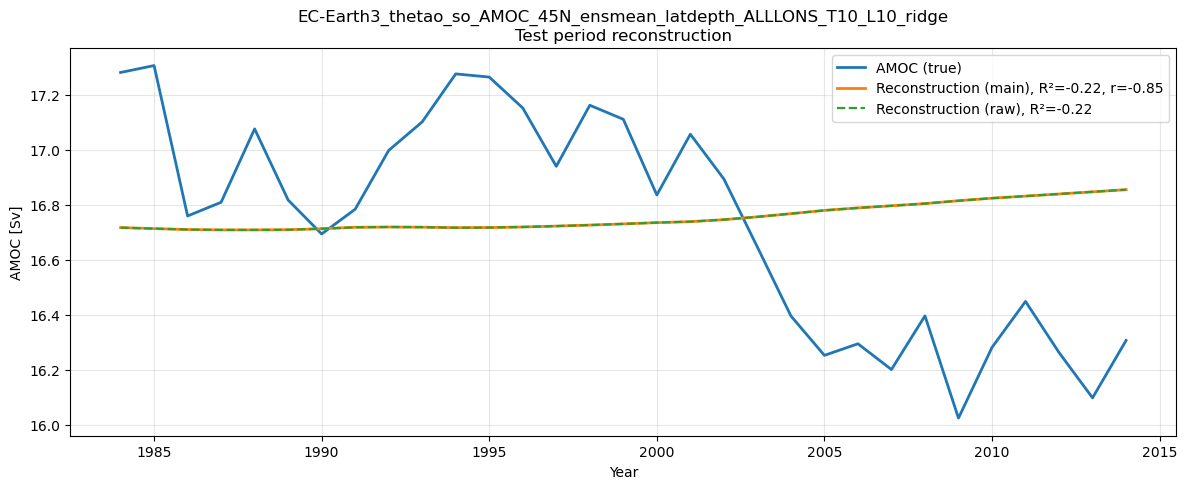

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/EC-Earth3/thetao_so_ALLLONS/EC-Earth3_thetao_so_AMOC_45N_ensmean_latdepth_ALLLONS_T10_L10_ridge_plot_timeseries.png


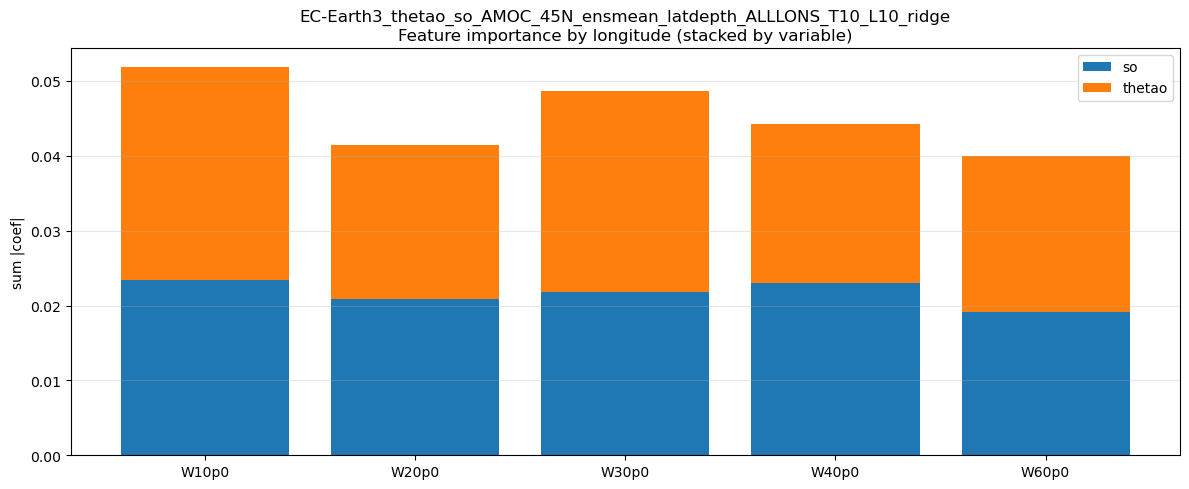

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/EC-Earth3/thetao_so_ALLLONS/EC-Earth3_thetao_so_AMOC_45N_ensmean_latdepth_ALLLONS_T10_L10_ridge_plot_importance_by_lon.png


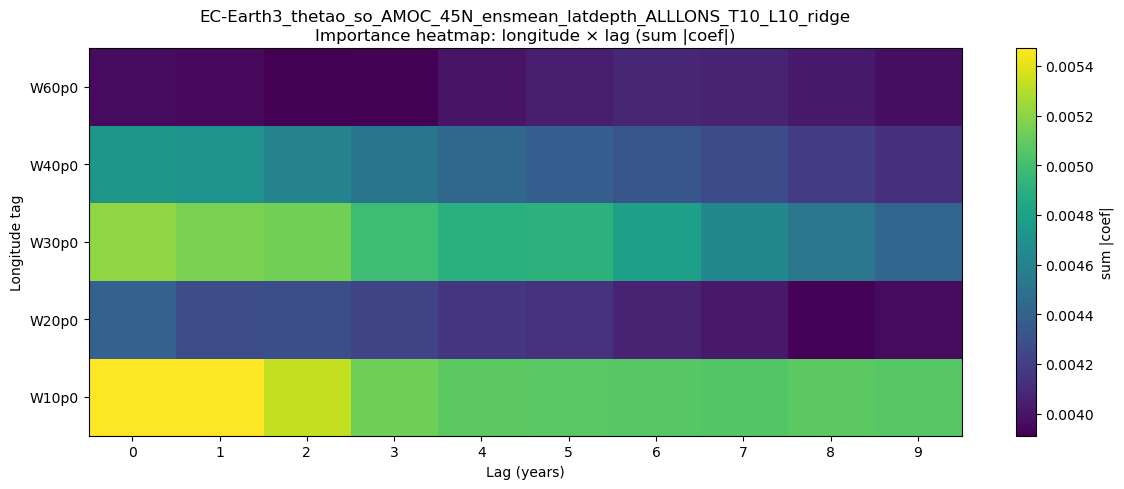

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/EC-Earth3/thetao_so_ALLLONS/EC-Earth3_thetao_so_AMOC_45N_ensmean_latdepth_ALLLONS_T10_L10_ridge_plot_importance_lon_x_lag.png

✅ DONE.
If you want a cleaner 'importance' measure than |coef|, we can add permutation importance on the test set.


In [12]:
#!/usr/bin/env python3
# ============================================================
# SUMMARY + PLOTS — ALL-LONGITUDES AMOC RECONSTRUCTION
#   1) Load saved reconstruction outputs
#   2) Print diagnostics + top errors
#   3) Summarize coefficient importance by:
#        - longitude (and variable)
#        - longitude × lag
#        - top individual features (var, lon, lag, mode)
#   4) Plot:
#        - time series (true vs pred)
#        - importance bar plot by longitude (stacked by var)
#        - optional heatmap of longitude × lag importance
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG — set this to your saved prefix (stem without _Ytrue.npy etc.)
# ============================================================

# Example:
# PREFIX = "/data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/CESM2/thetao_so_ALLLONS/CESM2_thetao_so_AMOC_45N_ensmean_latdepth_ALLLONS_T10_L10_ridge"
MODEL = "EC-Earth3"  # e.g. "CESM2", "IPSL-CM6A-LR", "MPI-ESM1-2-LR", "EC-Earth3"
METHOD = "ridge"
PREFIX = f"/data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/{MODEL}/thetao_so_ALLLONS/{MODEL}_thetao_so_AMOC_45N_ensmean_latdepth_ALLLONS_T10_L10_{METHOD}"

OUTDIR = os.path.dirname(PREFIX)
TAG = os.path.basename(PREFIX)

# plot settings
SHOW_RAW_IF_EXISTS = True
SAVE_FIGS = True
DPI = 300

# how many top items to print
TOPK_FEATURES = 20
TOPK_ERRORS = 10

# ============================================================
# HELPERS
# ============================================================

def to_1d(a):
    return np.asarray(a).squeeze().ravel()

def r2(y, yhat):
    y = to_1d(y); yhat = to_1d(yhat)
    ybar = y.mean()
    ss_tot = np.sum((y - ybar) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan, ss_res, ss_tot

def corr(y, yhat):
    y = to_1d(y); yhat = to_1d(yhat)
    if np.std(y) == 0 or np.std(yhat) == 0:
        return np.nan
    return float(np.corrcoef(y, yhat)[0, 1])

def mae(y, yhat):
    y = to_1d(y); yhat = to_1d(yhat)
    return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat):
    y = to_1d(y); yhat = to_1d(yhat)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def ensure_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

def group_sum_abs(coef_abs, feat_map, key_index):
    """
    coef_abs: (n_features,)
    feat_map: (n_features, 4) with [var, lon, lag, mode]
    key_index: which column(s) to group by: int or tuple of ints
    returns dict: key -> sum(|coef|)
    """
    if isinstance(key_index, int):
        key_index = (key_index,)

    out = {}
    for i in range(len(coef_abs)):
        key = tuple(feat_map[i, j] for j in key_index)
        out[key] = out.get(key, 0.0) + float(coef_abs[i])
    return out

def print_ranked(dct, topk=10, header=""):
    items = sorted(dct.items(), key=lambda kv: kv[1], reverse=True)
    if header:
        print("\n" + header)
        print("-" * len(header))
    for k, v in items[:topk]:
        print(f"{k}: {v:.6e}")
    return items

# ============================================================
# LOAD FILES
# ============================================================

ytrue_path = PREFIX + "_Ytrue.npy"
ypred_path = PREFIX + "_Ypred.npy"
time_path  = PREFIX + "_time.npy"
coef_path  = PREFIX + "_coef.npy"
fmap_path  = PREFIX + "_feature_map.npy"

ensure_exists(ytrue_path)
ensure_exists(ypred_path)
ensure_exists(time_path)
ensure_exists(coef_path)
ensure_exists(fmap_path)

Y_true = to_1d(np.load(ytrue_path))
Y_pred = to_1d(np.load(ypred_path))
time   = to_1d(np.load(time_path))
coef   = to_1d(np.load(coef_path))
feat_map = np.load(fmap_path, allow_pickle=True)  # dtype=object

# Optional raw pred
raw_path = PREFIX + "_Ypred_raw.npy"
has_raw = os.path.exists(raw_path)
Y_pred_raw = to_1d(np.load(raw_path)) if (has_raw and SHOW_RAW_IF_EXISTS) else None

# Optional meta
meta_path = PREFIX + "_meta.npy"
meta = np.load(meta_path, allow_pickle=True) if os.path.exists(meta_path) else None

# ============================================================
# METRICS + BASIC DIAGNOSTICS
# ============================================================

R2, ss_res, ss_tot = r2(Y_true, Y_pred)
R = corr(Y_true, Y_pred)
MAE = mae(Y_true, Y_pred)
RMSE = rmse(Y_true, Y_pred)
VR = float(np.std(Y_pred) / np.std(Y_true)) if np.std(Y_true) > 0 else np.nan

print("\n" + "=" * 70)
print("RECONSTRUCTION SUMMARY")
print("=" * 70)
print("PREFIX:", PREFIX)
print("N test points:", len(Y_true))
print("Years:", int(time[0]), "–", int(time[-1]))

print("\nTrue:")
print("  mean/std:", float(np.mean(Y_true)), float(np.std(Y_true)))
print("  min/max :", float(np.min(Y_true)), float(np.max(Y_true)))

print("\nPred (MAIN):")
print("  mean/std:", float(np.mean(Y_pred)), float(np.std(Y_pred)))
print("  min/max :", float(np.min(Y_pred)), float(np.max(Y_pred)))

print("\nMetrics (MAIN):")
print(f"  R²        = {R2:.4f}")
print(f"  corr      = {R:.4f}")
print(f"  var_ratio = {VR:.4f}   (std(pred)/std(true))")
print(f"  MAE       = {MAE:.4f}")
print(f"  RMSE      = {RMSE:.4f}")
print(f"  SS_res    = {ss_res:.6f}")
print(f"  SS_tot    = {ss_tot:.6f}")
print(f"  SS_res/SS_tot = {ss_res/ss_tot:.6f}" if ss_tot != 0 else "  SS_tot=0")

if meta is not None:
    print("\nmeta:", meta)

# Worst errors
err = Y_true - Y_pred
abs_err = np.abs(err)
worst = np.argsort(abs_err)[-min(TOPK_ERRORS, len(Y_true)):][::-1]

print("\nTop worst errors (MAIN):")
for idx in worst:
    print(f"  year={int(time[idx])} | true={Y_true[idx]:.4f} | pred={Y_pred[idx]:.4f} | err={err[idx]:+.4f}")

if Y_pred_raw is not None:
    R2r, _, _ = r2(Y_true, Y_pred_raw)
    Rr = corr(Y_true, Y_pred_raw)
    print(f"\nRaw pred present: R²_raw={R2r:.4f}, corr_raw={Rr:.4f}")

# ============================================================
# FEATURE IMPORTANCE SUMMARY (coef + feature_map)
# feature_map rows: (var, lon, lag, mode_index)
# ============================================================

coef_abs = np.abs(coef)
if len(coef_abs) != len(feat_map):
    raise ValueError(f"coef length {len(coef_abs)} != feature_map length {len(feat_map)}")

# group columns: 0 var, 1 lon, 2 lag, 3 mode
imp_by_lon = group_sum_abs(coef_abs, feat_map, key_index=1)                # lon
imp_by_var = group_sum_abs(coef_abs, feat_map, key_index=0)                # var
imp_by_var_lon = group_sum_abs(coef_abs, feat_map, key_index=(0, 1))       # var, lon
imp_by_lon_lag = group_sum_abs(coef_abs, feat_map, key_index=(1, 2))       # lon, lag

print("\n" + "=" * 70)
print("IMPORTANCE (sum of |coef|)")
print("=" * 70)

rank_lon = print_ranked(imp_by_lon, topk=20, header="By longitude")
rank_var = print_ranked(imp_by_var, topk=20, header="By variable")
rank_var_lon = print_ranked(imp_by_var_lon, topk=30, header="By variable × longitude (top 30)")

# Top individual features
idx_sorted = np.argsort(coef_abs)[::-1]
print(f"\nTop {TOPK_FEATURES} individual features by |coef|:")
for j in idx_sorted[:TOPK_FEATURES]:
    var, lon, lag, mode = feat_map[j]
    print(f"  |coef|={coef_abs[j]:.6e}  coef={coef[j]:+.6e}  ->  var={var}, lon={lon}, lag={lag}, mode={int(mode)+1}")

# ============================================================
# PREP DATA FOR PLOTS
# ============================================================

# Longitude list in preferred order (from feature_map)
lons = sorted(list({x for x in feat_map[:, 1]}), key=lambda s: (len(str(s)), str(s)))
vars_ = sorted(list({x for x in feat_map[:, 0]}), key=str)
lags = sorted(list({int(x) for x in feat_map[:, 2]}))

# stacked bars: importance by lon split by var
imp_lon_var = {lon: {var: 0.0 for var in vars_} for lon in lons}
for (var, lon), val in imp_by_var_lon.items():
    imp_lon_var[lon][var] += val

# heatmap: lon x lag
heat = np.zeros((len(lons), len(lags)), dtype=float)
for (lon, lag), val in imp_by_lon_lag.items():
    i = lons.index(lon)
    k = lags.index(int(lag))
    heat[i, k] = val

# ============================================================
# PLOTS
# ============================================================

# 1) Time series plot
plt.figure(figsize=(12, 5))
plt.plot(time, Y_true, lw=2, label="AMOC (true)")
plt.plot(time, Y_pred, lw=2, label=f"Reconstruction (main), R²={R2:.2f}, r={R:.2f}")

if Y_pred_raw is not None:
    R2r, _, _ = r2(Y_true, Y_pred_raw)
    plt.plot(time, Y_pred_raw, lw=1.6, linestyle="--",
             label=f"Reconstruction (raw), R²={R2r:.2f}")

plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{TAG}\nTest period reconstruction")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

fig1 = os.path.join(OUTDIR, TAG + "_plot_timeseries.png")
if SAVE_FIGS:
    plt.savefig(fig1, dpi=DPI)
plt.show()
print("Saved:", fig1)

# 2) Importance by longitude (stacked by var)
plt.figure(figsize=(12, 5))
x = np.arange(len(lons))
bottom = np.zeros(len(lons), dtype=float)

for var in vars_:
    vals = np.array([imp_lon_var[lon][var] for lon in lons], dtype=float)
    plt.bar(x, vals, bottom=bottom, label=str(var))
    bottom += vals

plt.xticks(x, lons)
plt.ylabel("sum |coef|")
plt.title(f"{TAG}\nFeature importance by longitude (stacked by variable)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

fig2 = os.path.join(OUTDIR, TAG + "_plot_importance_by_lon.png")
if SAVE_FIGS:
    plt.savefig(fig2, dpi=DPI)
plt.show()
print("Saved:", fig2)

# 3) Heatmap lon × lag importance
plt.figure(figsize=(12, 5))
plt.imshow(heat, aspect="auto", origin="lower")
plt.yticks(np.arange(len(lons)), lons)
plt.xticks(np.arange(len(lags)), lags)
plt.xlabel("Lag (years)")
plt.ylabel("Longitude tag")
plt.title(f"{TAG}\nImportance heatmap: longitude × lag (sum |coef|)")
plt.colorbar(label="sum |coef|")
plt.tight_layout()

fig3 = os.path.join(OUTDIR, TAG + "_plot_importance_lon_x_lag.png")
if SAVE_FIGS:
    plt.savefig(fig3, dpi=DPI)
plt.show()
print("Saved:", fig3)

print("\n✅ DONE.")
print("If you want a cleaner 'importance' measure than |coef|, we can add permutation importance on the test set.")


### Feature reduction

Loading EOF PCs...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)
Building FULL feature matrix...
X_full: (155, 1000) Y_full: (155,)

Fitting BASELINE (all groups)...
✓ BASE alpha=10  R²=0.8421  corr=0.9405  var_ratio=0.7647

Top 20 groups (var, lon, mode) by summed |coef| over lags:
  so      W10p0  mode10   importance=5.785847e-02
  so      W60p0  mode04   importance=5.091650e-02
  so      W10p0  mode07   importance=5.005607e-02
  so      W60p0  mode05   importance=4.944243e-02
  so      W60p0  mode08   importance=4.855650e-02
  thetao  W20p0  mode10   importance=4.802720e-02
  so      W40p0  mode09   importance=4.735568e-02
  thetao  W60p0  mode08   importance=4.612110e-02
  so      W60p0  mode0

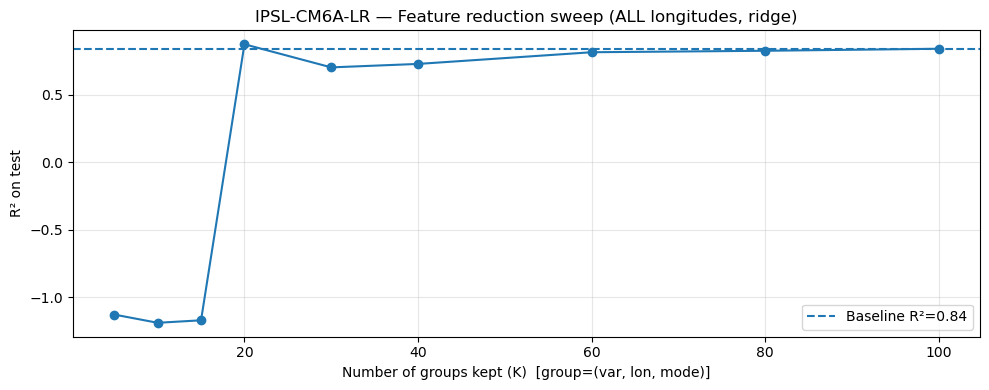

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/Feature_reduction/thetao_so_ALLLONS_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_sweep_R2_vs_K.png


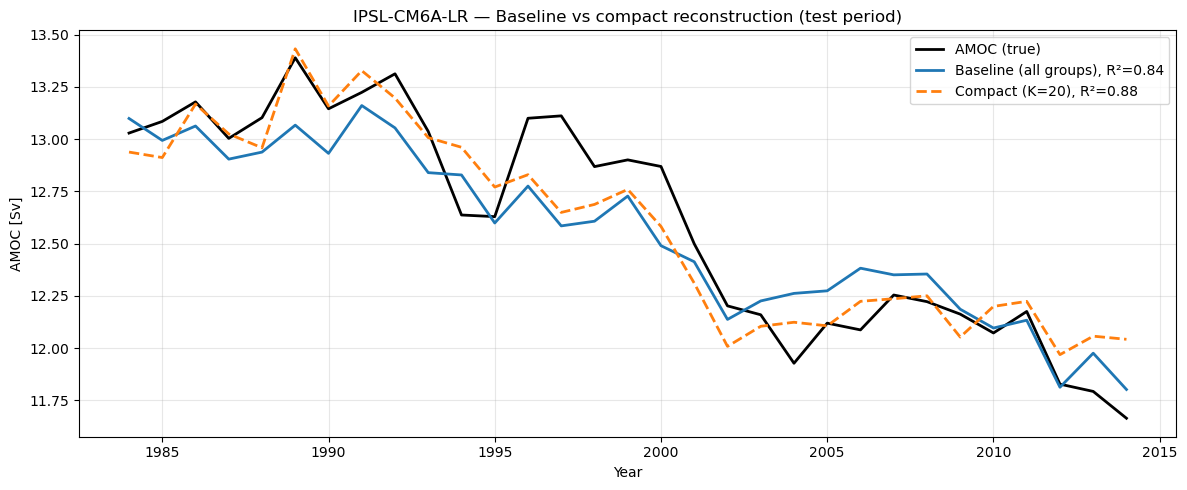

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/Feature_reduction/thetao_so_ALLLONS_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_baseline_vs_compact_timeseries.png


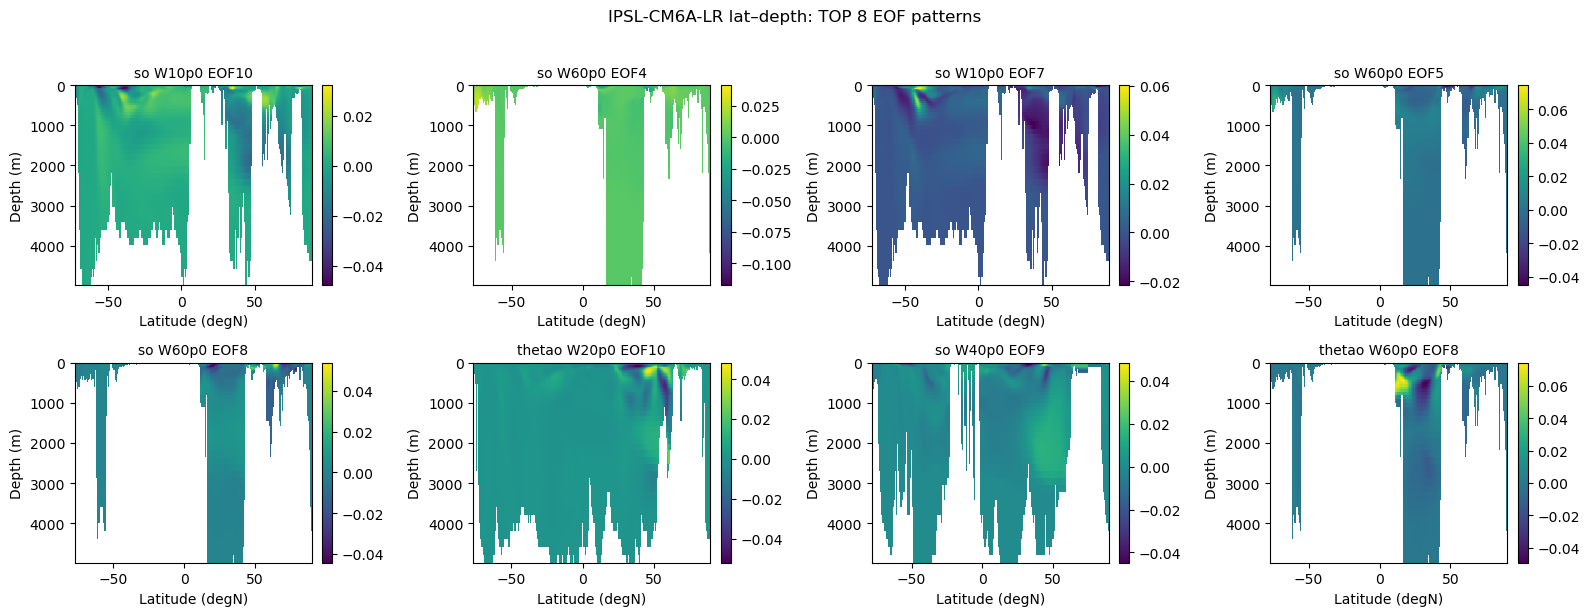

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/Feature_reduction/thetao_so_ALLLONS_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_latdepth_selected_TOP8_EOF_maps.png


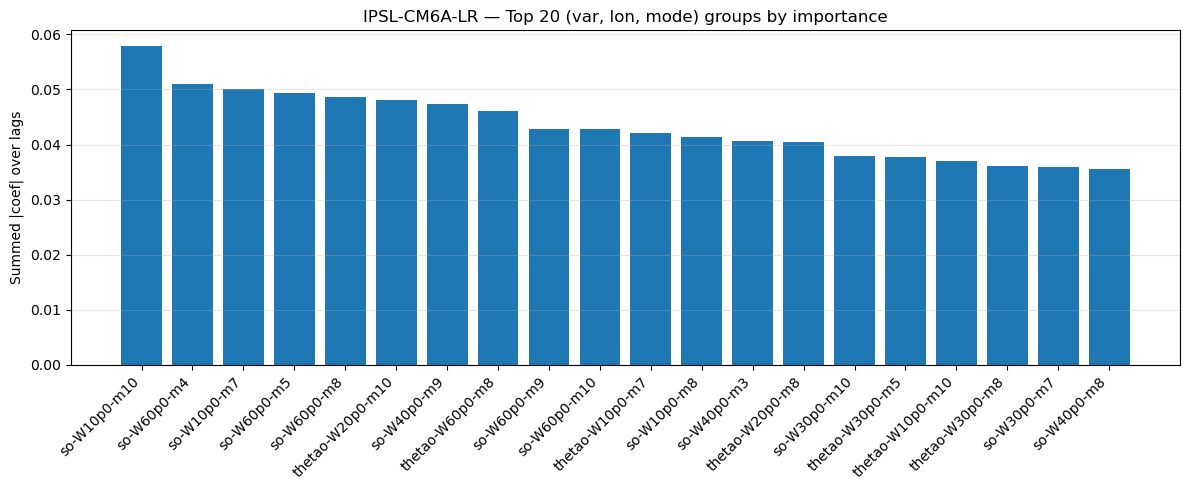

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/Feature_reduction/thetao_so_ALLLONS_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_top_groups_importance.png

✅ DONE.
Baseline prefix: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/Feature_reduction/thetao_so_ALLLONS_MODESEL/IPSL-CM6A-LR_thetao_so_AMOC_45N_ensmean_ALLLONS_BASE_T10_L10
Compact  prefix: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/Feature_reduction/thetao_so_ALLLONS_MODESEL/IPSL-CM6A-LR_thetao_so_AMOC_45N_ensmean_ALLLONS_COMPACT_K20_T10_L10


In [ ]:
#!/usr/bin/env python3
"""
FEATURE REDUCTION EXPERIMENT — ALL LONGITUDES (Ridge)
-----------------------------------------------------
Goal:
  Keep reconstruction skill (R²) while using fewer modes/features.

Approach:
  1) Build full feature matrix from all longitudes, both vars, all modes, all lags
  2) Fit ridge baseline (alpha scan) on TRAIN
  3) Compute group importance from |coef|, grouped by (var, lon, mode), summed over lags
  4) Progressive pruning:
       keep top-K groups, rebuild X using only those groups (all lags preserved),
       refit ridge (alpha scan) and evaluate on TEST
  5) Make plots:
       - R² vs number of groups K
       - Timeseries plot for baseline vs best compact model
       - Bar plot of selected groups (importance)

Outputs saved in OUTDIR:
  - *_sweep_metrics.npy
  - *_group_ranking.npy
  - *_selected_groups_K<...>.npy
  - Baseline reconstruction arrays
  - Compact reconstruction arrays
  - Plots (png)
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"  # e.g. "CESM2", "IPSL-CM6A-LR", "MPI-ESM1-2-LR", "EC-Earth3"
TARGET = "AMOC_45N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]

N_MODES = 10
N_LAGS  = 10
TEST_FRAC = 0.2

RIDGE_ALPHAS = [1, 10]

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"  

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Lat_depth/{TARGET}/{MODEL}/Feature_reduction/" + "_".join(VARS) + "_ALLLONS_MODESEL/"
os.makedirs(OUTDIR, exist_ok=True)

# Sweep settings: how many top groups to try
# Total groups = len(VARS)*len(LON_TAGS)*N_MODES (e.g. 2*5*10=100)
K_LIST = [5, 10, 15, 20, 30, 40, 60, 80, 100]

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC  # (year, mode)

def build_X(pc_dict, years, n_lags, allowed_groups=None):
    """
    pc_dict[(var,lon)] -> DataArray(year, mode)
    allowed_groups: set of (var, lon, mode_index) to keep (mode_index is 0-based).
                    If None => keep all groups.
    Returns:
      X (T-n_lags, n_features)
      feat_map (n_features, 4): (var, lon, lag, mode_index)
      time_out (T-n_lags,)
    """
    years = np.asarray(years).astype(int)
    T = len(years)

    # pre-fetch arrays
    pc_np = {k: v.sel(year=years).values for k, v in pc_dict.items()}  # (T, n_modes)

    keys_ordered = [(var, lon) for var in VARS for lon in LON_TAGS]

    feat_map = []
    X = []
    time_out = []

    # Build rows
    for t in range(n_lags, T):
        feats = []
        for lag in range(n_lags):
            for (var, lon) in keys_ordered:
                arr = pc_np[(var, lon)][t - lag, :]  # (n_modes,)
                if allowed_groups is None:
                    # keep all modes
                    for m in range(arr.shape[0]):
                        feats.append(arr[m])
                        feat_map.append((var, lon, lag, m))
                else:
                    # keep only allowed (var, lon, mode)
                    for m in range(arr.shape[0]):
                        if (var, lon, m) in allowed_groups:
                            feats.append(arr[m])
                            feat_map.append((var, lon, lag, m))
        X.append(feats)
        time_out.append(years[t])

    X = np.asarray(X, dtype=float)
    feat_map = np.array(feat_map, dtype=object).reshape(len(X), -1, 4)[0]  # same for all rows
    # Trick: feat_map appended for every row; but ordering is identical each row.
    # We reshape and take the first row's feature map.
    return X, feat_map, np.asarray(time_out)

def fit_ridge_alpha_scan(X_train, Y_train, X_test, Y_test, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
        mdl.fit(X_train, Y_train)
        pred_test = mdl.predict(X_test)
        r2 = float(r2_score(Y_test, pred_test))
        if best is None or r2 > best["r2"]:
            best = {"alpha": a, "model": mdl, "pred_test": pred_test, "r2": r2}
    # also compute train preds for potential debugging
    best["pred_train"] = best["model"].predict(X_train)
    return best

def compute_group_importance(coef, feat_map):
    """
    Group by (var, lon, mode) and sum |coef| over all lags.
    coef: (n_features,)
    feat_map: (n_features,4) tuples (var, lon, lag, mode)
    """
    coef_abs = np.abs(coef)
    imp = {}
    for i in range(len(coef_abs)):
        var, lon, lag, mode = feat_map[i]
        key = (var, lon, int(mode))
        imp[key] = imp.get(key, 0.0) + float(coef_abs[i])
    return imp

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return r2, r, var_ratio, mae, rmse

# ============================================================
# LOAD PCs
# ============================================================

print("Loading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc(var, lon, N_MODES)
        print(f"  ✓ {var} {lon} PC:", tuple(pc_dict[(var, lon)].shape))

# ============================================================
# LOAD AMOC + COMMON YEARS
# ============================================================

print("Loading AMOC...")
dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET].squeeze()
AMOC_years = extract_years(AMOC_da["time"])
AMOC_da = AMOC_da.assign_coords(year=("time", AMOC_years)).swap_dims({"time": "year"}).drop_vars("time")

common_years = AMOC_da["year"].values
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values)

common_years = np.asarray(common_years).astype(int)
common_years.sort()

AMOC = AMOC_da.sel(year=common_years).values.squeeze()
if AMOC.ndim != 1:
    raise ValueError(f"AMOC not 1D after squeeze: shape={AMOC.shape}")

print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

# ============================================================
# BUILD FULL X/Y
# ============================================================

print("Building FULL feature matrix...")
X_full, feat_map_full, time_out = build_X(pc_dict, common_years, N_LAGS, allowed_groups=None)
Y_full = AMOC[N_LAGS:]

print("X_full:", X_full.shape, "Y_full:", Y_full.shape)

# Train/test split
n_train = int((1 - TEST_FRAC) * len(X_full))
Xtr, Xte = X_full[:n_train], X_full[n_train:]
Ytr, Yte = Y_full[:n_train], Y_full[n_train:]
t_test = time_out[n_train:]

# ============================================================
# BASELINE FIT
# ============================================================

print("\nFitting BASELINE (all groups)...")
base = fit_ridge_alpha_scan(Xtr, Ytr, Xte, Yte, RIDGE_ALPHAS)
base_alpha = base["alpha"]
base_pred = base["pred_test"]
base_model = base["model"]
base_coef = base_model.named_steps["ridge"].coef_

base_metrics = metrics(Yte, base_pred)
print(f"✓ BASE alpha={base_alpha}  R²={base_metrics[0]:.4f}  corr={base_metrics[1]:.4f}  var_ratio={base_metrics[2]:.4f}")

# Save baseline outputs
tag_base = f"{MODEL}_{'_'.join(VARS)}_{TARGET}_ALLLONS_BASE_T{N_MODES}_L{N_LAGS}"
pref_base = os.path.join(OUTDIR, tag_base)
np.save(pref_base + "_Ytrue.npy", Yte.astype(np.float32))
np.save(pref_base + "_Ypred_raw.npy", base_pred.astype(np.float32))
np.save(pref_base + "_Ypred.npy", base_pred.astype(np.float32))
np.save(pref_base + "_time.npy", t_test.astype(int))
np.save(pref_base + "_coef.npy", base_coef.astype(np.float32))
np.save(pref_base + "_feature_map.npy", feat_map_full)
np.save(pref_base + "_meta.npy", np.array([base_alpha, base_metrics[0], base_metrics[1], base_metrics[2]], dtype=float))

# ============================================================
# RANK GROUPS (var, lon, mode)
# ============================================================

imp = compute_group_importance(base_coef, feat_map_full)
ranked = sorted(imp.items(), key=lambda kv: kv[1], reverse=True)

print("\nTop 20 groups (var, lon, mode) by summed |coef| over lags:")
for (key, val) in ranked[:20]:
    var, lon, mode = key
    print(f"  {var:6s}  {lon:5s}  mode{mode+1:02d}   importance={val:.6e}")

# Save ranking
rank_arr = np.array([(k[0], k[1], int(k[2]), float(v)) for k, v in ranked], dtype=object)
np.save(os.path.join(OUTDIR, f"{MODEL}_{TARGET}_group_ranking.npy"), rank_arr)

# ============================================================
# SWEEP: KEEP TOP-K GROUPS
# ============================================================

print("\nProgressive pruning sweep...")
sweep_rows = []  # (K, n_features, best_alpha, r2, corr, var_ratio, mae, rmse)

total_groups = len(ranked)
for K in K_LIST:
    K = min(K, total_groups)
    topK = set([ranked[i][0] for i in range(K)])  # keys are (var, lon, mode)

    # Build reduced X with only those groups (all lags preserved)
    X_red, feat_map_red, _ = build_X(pc_dict, common_years, N_LAGS, allowed_groups=topK)
    Y_red = AMOC[N_LAGS:]

    # Split same way
    Xtr2, Xte2 = X_red[:n_train], X_red[n_train:]
    Ytr2, Yte2 = Y_red[:n_train], Y_red[n_train:]

    bestK = fit_ridge_alpha_scan(Xtr2, Ytr2, Xte2, Yte2, RIDGE_ALPHAS)
    predK = bestK["pred_test"]
    metK = metrics(Yte2, predK)

    sweep_rows.append([K, X_red.shape[1], bestK["alpha"], *metK])
    print(f"  K={K:3d}  feats={X_red.shape[1]:4d}  alpha={bestK['alpha']:<8g}  R²={metK[0]: .4f}  corr={metK[1]: .4f}  var={metK[2]: .3f}")

sweep = np.array(sweep_rows, dtype=float)
np.save(os.path.join(OUTDIR, f"{MODEL}_{TARGET}_sweep_metrics.npy"), sweep)

# pick best compact by highest R² (or you can use a threshold later)
best_idx = int(np.argmax(sweep[:, 3]))  # column 3 is R²
bestK = int(sweep[best_idx, 0])
best_feats = int(sweep[best_idx, 1])
best_alphaK = float(sweep[best_idx, 2])
best_r2K = float(sweep[best_idx, 3])

print(f"\n✓ Best compact in sweep: K={bestK} groups  ({best_feats} feats)  alpha={best_alphaK}  R²={best_r2K:.4f}")

# Refit bestK to save arrays
topK = set([ranked[i][0] for i in range(bestK)])
X_red, feat_map_red, time_out2 = build_X(pc_dict, common_years, N_LAGS, allowed_groups=topK)
Y_red = AMOC[N_LAGS:]
Xtr2, Xte2 = X_red[:n_train], X_red[n_train:]
Ytr2, Yte2 = Y_red[:n_train], Y_red[n_train:]
t_test2 = time_out2[n_train:]

best_modelK = fit_ridge_alpha_scan(Xtr2, Ytr2, Xte2, Yte2, RIDGE_ALPHAS)
predK = best_modelK["pred_test"]
coefK = best_modelK["model"].named_steps["ridge"].coef_
metK = metrics(Yte2, predK)

# Save compact outputs
tag_comp = f"{MODEL}_{'_'.join(VARS)}_{TARGET}_ALLLONS_COMPACT_K{bestK}_T{N_MODES}_L{N_LAGS}"
pref_comp = os.path.join(OUTDIR, tag_comp)
np.save(pref_comp + "_Ytrue.npy", Yte2.astype(np.float32))
np.save(pref_comp + "_Ypred_raw.npy", predK.astype(np.float32))
np.save(pref_comp + "_Ypred.npy", predK.astype(np.float32))
np.save(pref_comp + "_time.npy", t_test2.astype(int))
np.save(pref_comp + "_coef.npy", coefK.astype(np.float32))
np.save(pref_comp + "_feature_map.npy", feat_map_red)
np.save(pref_comp + "_meta.npy", np.array([best_modelK["alpha"], metK[0], metK[1], metK[2], bestK], dtype=float))
np.save(pref_comp + "_selected_groups.npy", np.array(list(topK), dtype=object))

# ============================================================
# PLOTS
# ============================================================

# 1) R² vs K
plt.figure(figsize=(10, 4))
plt.plot(sweep[:, 0], sweep[:, 3], marker="o")
plt.axhline(base_metrics[0], linestyle="--", label=f"Baseline R²={base_metrics[0]:.2f}")
plt.xlabel("Number of groups kept (K)  [group=(var, lon, mode)]")
plt.ylabel("R² on test")
plt.title(f"{MODEL} — Feature reduction sweep (ALL longitudes, ridge)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f1 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_sweep_R2_vs_K.png")
plt.savefig(f1, dpi=300)
plt.show()
print("Saved:", f1)

# 2) Timeseries comparison (baseline vs best compact)
plt.figure(figsize=(12, 5))
plt.plot(t_test, Yte, lw=2, color="black", label="AMOC (true)")
plt.plot(t_test, base_pred, lw=2, label=f"Baseline (all groups), R²={base_metrics[0]:.2f}")
plt.plot(t_test2, predK, lw=2, linestyle="--", label=f"Compact (K={bestK}), R²={metK[0]:.2f}")
plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} — Baseline vs compact reconstruction (test period)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f2 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_baseline_vs_compact_timeseries.png")
plt.savefig(f2, dpi=300)
plt.show()
print("Saved:", f2)

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import os

# ============================================================
# PLOT HELPERS — LAT–DEPTH EOF MAP
# ============================================================

def plot_latdepth_eof(ax, lat, lev, eof, title=""):
    """
    lat: 1D latitude (nlat,)
    lev: 1D depth (nlev,) (usually meters)
    eof: 2D (nlev, nlat) or (nlat, nlev) -> we handle both
    """
    eof = np.asarray(eof)

    # make sure eof is (lev, lat)
    if eof.shape == (len(lat), len(lev)):
        eof = eof.T
    if eof.shape != (len(lev), len(lat)):
        raise ValueError(f"EOF shape {eof.shape} does not match (lev,lat)=({len(lev)},{len(lat)})")

    m = ax.pcolormesh(lat, lev, eof, shading="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Latitude (degN)")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()  # ocean depth downwards
    plt.colorbar(m, ax=ax, fraction=0.046, pad=0.04)

def load_latdepth_grid(ds):
    """
    Try common coord names for lat-depth sections.
    Returns lat (1D), lev (1D).
    """
    # latitude
    if "lat" in ds:
        lat = ds["lat"].values
    elif "latitude" in ds:
        lat = ds["latitude"].values
    elif "y" in ds and "nav_lat" in ds.coords:
        lat = ds["nav_lat"].values
    else:
        # fallback: try coords
        for name in ds.coords:
            if "lat" in name.lower():
                lat = ds[name].values
                break
        else:
            raise KeyError("Could not find latitude coordinate in dataset")

    # depth
    if "lev" in ds:
        lev = ds["lev"].values
    elif "depth" in ds:
        lev = ds["depth"].values
    elif "z" in ds:
        lev = ds["z"].values
    else:
        for name in ds.coords:
            if "lev" in name.lower() or "depth" in name.lower():
                lev = ds[name].values
                break
        else:
            raise KeyError("Could not find depth coordinate in dataset")

    lat = np.asarray(lat).astype(float).squeeze()
    lev = np.asarray(lev).astype(float).squeeze()
    return lat, lev

# ============================================================
# 3) EOF MAPS FOR SELECTED GROUPS (LAT–DEPTH)
# ============================================================

TOP_EOF_PLOTS = 8

final_selected = [ranked[i][0] for i in range(min(bestK, TOP_EOF_PLOTS))]

ncols = 4
nrows = int(np.ceil(len(final_selected) / ncols))

plt.figure(figsize=(4 * ncols, 3 * nrows))

for i, (var, lon_tag, mode) in enumerate(final_selected):
    ax = plt.subplot(nrows, ncols, i + 1)

    eof_file = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(eof_file):
        ax.set_title(f"MISSING\n{var} {lon_tag} EOF{int(mode)+1}", fontsize=9)
        ax.axis("off")
        continue

    ds = xr.open_dataset(eof_file)
    EOF = ds["EOF"].isel(mode=int(mode)).values

    lat, lev = load_latdepth_grid(ds)

    plot_latdepth_eof(
        ax, lat, lev, EOF,
        title=f"{var} {lon_tag} EOF{int(mode)+1}"
    )

plt.suptitle(f"{MODEL} lat–depth: TOP {TOP_EOF_PLOTS} EOF patterns", y=1.02)
plt.tight_layout()

f_ld = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_latdepth_selected_TOP{TOP_EOF_PLOTS}_EOF_maps.png")
plt.savefig(f_ld, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", f_ld)


# 4) Bar plot: importance of top 20 groups
topN = 20
labels = [f"{k[0]}-{k[1]}-m{k[2]+1}" for k, _ in ranked[:topN]]
vals = [v for _, v in ranked[:topN]]

plt.figure(figsize=(12, 5))
plt.bar(range(topN), vals)
plt.xticks(range(topN), labels, rotation=45, ha="right")
plt.ylabel("Summed |coef| over lags")
plt.title(f"{MODEL} — Top {topN} (var, lon, mode) groups by importance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
f3 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_top_groups_importance.png")
plt.savefig(f3, dpi=300)
plt.show()
print("Saved:", f3)

print("\n✅ DONE.")
print("Baseline prefix:", pref_base)
print("Compact  prefix:", pref_comp)


### Lag feature reduction

Loading EOF PCs...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)

Testing N_LAGS = 1
BASE: alpha=100       R²=+0.7715  corr=+0.9554  var=0.858  feats=100
  K=  5 feats=   5 alpha=0.0001   R²=+0.7222 corr=+0.9373 var=0.925
  K=  8 feats=   8 alpha=100      R²=+0.7059 corr=+0.9407 var=0.786
  K= 10 feats=  10 alpha=0.0001   R²=+0.8309 corr=+0.9244 var=0.818
  K= 12 feats=  12 alpha=10       R²=+0.7548 corr=+0.8990 var=0.730
  K= 15 feats=  15 alpha=1        R²=+0.7739 corr=+0.8900 var=0.778
  K= 20 feats=  20 alpha=10       R²=+0.8153 corr=+0.9116 var=0.844
  K= 30 feats=  30 alpha=100      R²=+0.7898 corr=+0.9375 var=0.741
  K= 40 feats=  40 alpha=100      R²=+0.7779 corr=+0.9481 var=0.815
  K= 60 

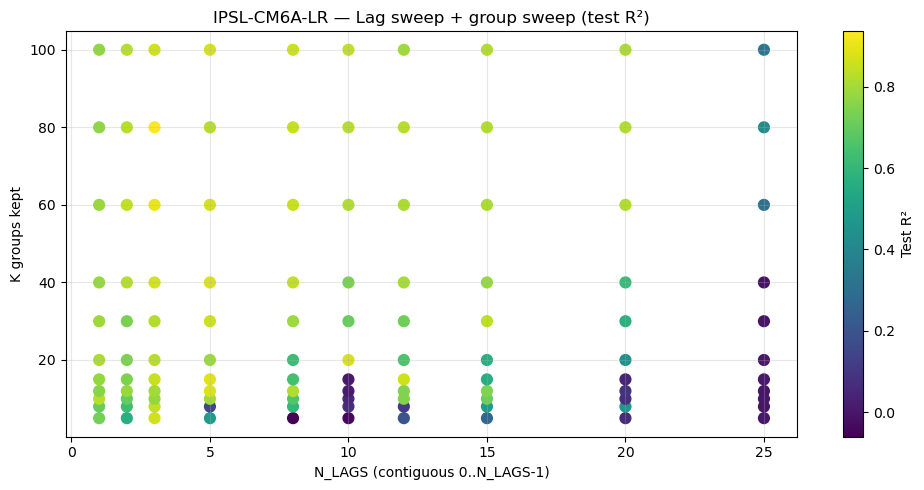

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/Feature_reduction/thetao_so_ALLLONS_LAGSWEEP_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_lag_vs_K_scatter_R2.png


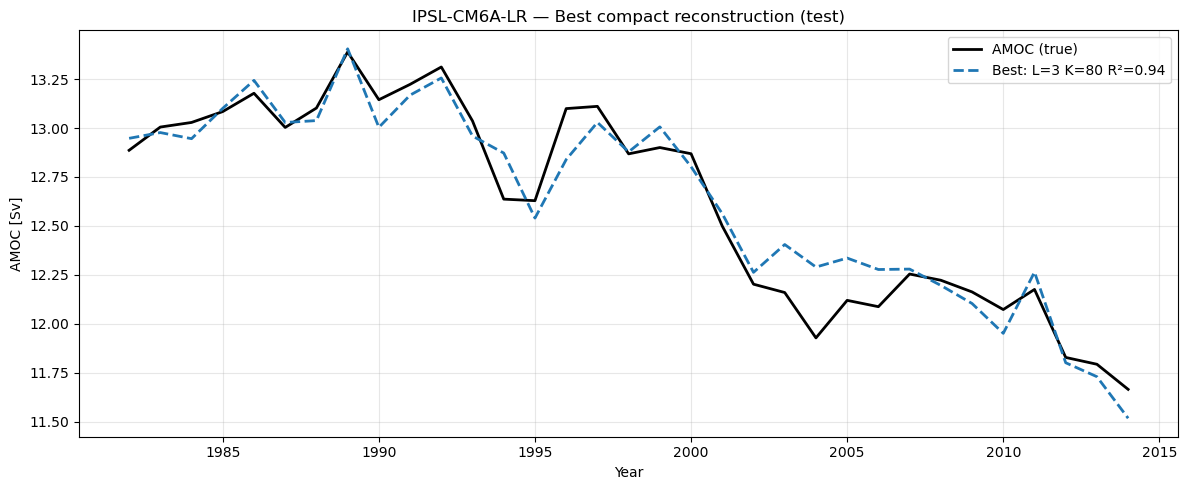

Saved: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/Feature_reduction/thetao_so_ALLLONS_LAGSWEEP_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_best_timeseries.png

✅ DONE.


In [10]:
#!/usr/bin/env python3
"""
EFFECTIVE FEATURE REDUCTION — LAG SWEEP + MODE(GROUP) SWEEP (Ridge)
-------------------------------------------------------------------
Keeps your WORKING indexing convention (no calendar-year fancy stuff).

For each N_LAGS in N_LAGS_LIST:
  1) Build full X with all groups across all longitudes/vars/modes for those lags
  2) Fit ridge baseline (alpha scan) on TRAIN
  3) Rank groups (var, lon, mode) by summed |coef| over lags
  4) For each K in K_LIST: rebuild X keeping only top-K groups (all lags preserved), refit, score
Collect all results and choose:
  - best R² OR smallest features above threshold

This is robust because ranking only happens when baseline is meaningful.
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]

N_MODES = 10
TEST_FRAC = 0.2

RIDGE_ALPHAS = [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000, 1e4, 1e5]

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Lat_depth/{TARGET}/{MODEL}/Feature_reduction/" \
         + "_".join(VARS) + "_ALLLONS_LAGSWEEP_MODESEL/"
os.makedirs(OUTDIR, exist_ok=True)

# Sweep lags (contiguous 0..N_LAGS-1). Start small; 50 is usually too aggressive.
N_LAGS_LIST = [1, 2, 3, 5, 8, 10, 12, 15, 20, 25]

# Mode/group sweep
# groups = (var, lon, mode). Total=2*5*10=100
K_LIST = [5, 8, 10, 12, 15, 20, 30, 40, 60, 80, 100]

# ============================================================
# HELPERS (mostly your working ones)
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))
    if "member" in PC.dims:
        PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC  # (year, mode)

def build_X(pc_dict, years, n_lags, allowed_groups=None):
    """
    EXACTLY your working indexing:
      row t uses target year years[t], with predictors from indices (t-lag)
    """
    years = np.asarray(years).astype(int)
    T = len(years)

    pc_np = {k: v.sel(year=years).values for k, v in pc_dict.items()}  # (T, n_modes)
    keys_ordered = [(var, lon) for var in VARS for lon in LON_TAGS]

    feat_map = []
    X = []
    time_out = []

    for t in range(n_lags, T):
        feats = []
        local_fmap = []

        for lag in range(n_lags):
            for (var, lon) in keys_ordered:
                arr = pc_np[(var, lon)][t - lag, :]  # (n_modes,)
                if allowed_groups is None:
                    for m in range(arr.shape[0]):
                        feats.append(arr[m])
                        local_fmap.append((var, lon, lag, m))
                else:
                    for m in range(arr.shape[0]):
                        if (var, lon, m) in allowed_groups:
                            feats.append(arr[m])
                            local_fmap.append((var, lon, lag, m))

        X.append(feats)
        time_out.append(years[t])
        if t == n_lags:
            feat_map = np.array(local_fmap, dtype=object)  # one-time map

    return np.asarray(X, dtype=float), feat_map, np.asarray(time_out, dtype=int)

def fit_ridge_alpha_scan(X_train, Y_train, X_test, Y_test, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(a)))
        mdl.fit(X_train, Y_train)
        pred = mdl.predict(X_test)
        r2 = float(r2_score(Y_test, pred))
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "model": mdl, "pred": pred, "r2": r2}
    best["coef"] = best["model"].named_steps["ridge"].coef_.astype(float)
    return best

def compute_group_importance(coef, feat_map):
    """
    Group by (var, lon, mode), sum |coef| over all lags.
    """
    coef_abs = np.abs(np.asarray(coef).ravel())
    imp = {}
    for i in range(len(coef_abs)):
        var, lon, lag, mode = feat_map[i]
        key = (str(var), str(lon), int(mode))
        imp[key] = imp.get(key, 0.0) + float(coef_abs[i])
    ranked = sorted(imp.items(), key=lambda kv: kv[1], reverse=True)
    return ranked  # list of ((var,lon,mode), score)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return r2, r, var_ratio, mae, rmse

# ============================================================
# LOAD PCs
# ============================================================

print("Loading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc(var, lon, N_MODES)
        print(f"  ✓ {var} {lon} PC:", tuple(pc_dict[(var, lon)].shape))

# ============================================================
# LOAD AMOC + COMMON YEARS
# ============================================================

print("Loading AMOC...")
dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET].squeeze()
AMOC_years = extract_years(AMOC_da["time"])
AMOC_da = AMOC_da.assign_coords(year=("time", AMOC_years)).swap_dims({"time": "year"}).drop_vars("time")

common_years = AMOC_da["year"].values
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values)
common_years = np.asarray(common_years).astype(int)
common_years.sort()

AMOC = AMOC_da.sel(year=common_years).values.squeeze()
print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

# ============================================================
# MAIN SWEEP
# ============================================================

all_rows = []
best_overall = None

for N_LAGS in N_LAGS_LIST:
    if N_LAGS >= len(common_years) - 10:
        continue

    print(f"\n==============================")
    print(f"Testing N_LAGS = {N_LAGS}")
    print(f"==============================")

    # Build full X/Y
    X_full, fmap_full, time_out = build_X(pc_dict, common_years, N_LAGS, allowed_groups=None)
    Y_full = AMOC[N_LAGS:]

    # Split
    n_train = int((1 - TEST_FRAC) * len(X_full))
    Xtr, Xte = X_full[:n_train], X_full[n_train:]
    Ytr, Yte = Y_full[:n_train], Y_full[n_train:]
    t_test = time_out[n_train:]

    # Baseline
    base = fit_ridge_alpha_scan(Xtr, Ytr, Xte, Yte, RIDGE_ALPHAS)
    base_met = metrics(Yte, base["pred"])
    print(f"BASE: alpha={base['alpha']:<8g}  R²={base_met[0]:+.4f}  corr={base_met[1]:+.4f}  var={base_met[2]:.3f}  feats={X_full.shape[1]}")

    # If baseline is already terrible, don't trust rankings. Still record it, but be cautious.
    ranked_groups = compute_group_importance(base["coef"], fmap_full)

    # Save baseline per N_LAGS
    pref = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_BASE_L{N_LAGS}")
    np.save(pref + "_Ytrue.npy", Yte.astype(np.float32))
    np.save(pref + "_Ypred.npy", base["pred"].astype(np.float32))
    np.save(pref + "_time.npy", t_test.astype(int))
    np.save(pref + "_meta.npy", np.array([base['alpha'], *base_met, N_LAGS, X_full.shape[1]], dtype=float))
    np.save(pref + "_group_ranking.npy",
            np.array([(k[0], k[1], int(k[2]), float(v)) for k, v in ranked_groups], dtype=object))

    # Sweep K groups for this N_LAGS
    for K in K_LIST:
        K = min(K, len(ranked_groups))
        keep = set([ranked_groups[i][0] for i in range(K)])  # (var,lon,mode)

        Xk, fmap_k, _ = build_X(pc_dict, common_years, N_LAGS, allowed_groups=keep)
        Yk = AMOC[N_LAGS:]
        Xtr2, Xte2 = Xk[:n_train], Xk[n_train:]
        Ytr2, Yte2 = Yk[:n_train], Yk[n_train:]

        res = fit_ridge_alpha_scan(Xtr2, Ytr2, Xte2, Yte2, RIDGE_ALPHAS)
        met = metrics(Yte2, res["pred"])

        row = [N_LAGS, K, Xk.shape[1], res["alpha"], *met, base_met[0]]
        all_rows.append(row)

        print(f"  K={K:3d} feats={Xk.shape[1]:4d} alpha={res['alpha']:<8g} R²={met[0]:+.4f} corr={met[1]:+.4f} var={met[2]:.3f}")

        # track best overall by test R²
        if best_overall is None or met[0] > best_overall["r2"]:
            best_overall = {
                "N_LAGS": N_LAGS, "K": K, "keep": keep,
                "alpha": res["alpha"], "r2": met[0],
                "pred": res["pred"], "Yte": Yte2, "t_test": t_test
            }

# Save sweep table
all_rows = np.array(all_rows, dtype=float)
np.save(os.path.join(OUTDIR, f"{MODEL}_{TARGET}_LAGSWEEP_GROUPSWEEP.npy"), all_rows)

print("\n======================================")
print("BEST OVERALL (by test R²)")
print("======================================")
print(best_overall)

# Plot: heatmap-like scatter (N_LAGS vs K colored by R²)
plt.figure(figsize=(10, 5))
plt.scatter(all_rows[:, 0], all_rows[:, 1], c=all_rows[:, 4], s=60)
plt.colorbar(label="Test R²")
plt.xlabel("N_LAGS (contiguous 0..N_LAGS-1)")
plt.ylabel("K groups kept")
plt.title(f"{MODEL} — Lag sweep + group sweep (test R²)")
plt.grid(alpha=0.3)
plt.tight_layout()
f0 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_lag_vs_K_scatter_R2.png")
plt.savefig(f0, dpi=300)
plt.show()
print("Saved:", f0)

# Plot: best model timeseries vs truth
plt.figure(figsize=(12, 5))
plt.plot(best_overall["t_test"], best_overall["Yte"], lw=2, color="black", label="AMOC (true)")
plt.plot(best_overall["t_test"], best_overall["pred"], lw=2, linestyle="--",
         label=f"Best: L={best_overall['N_LAGS']} K={best_overall['K']} R²={best_overall['r2']:.2f}")
plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} — Best compact reconstruction (test)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f1 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_best_timeseries.png")
plt.savefig(f1, dpi=300)
plt.show()
print("Saved:", f1)

print("\n✅ DONE.")


### Feature reduction with lasso

Loading EOF PCs...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)
Building FULL X using ALL lags 0..49 ...
X_full: (115, 5000) Y_full: (115,)

Stability selection on TRAIN: B=200, subsample=0.70
  bootstrap  25/200: alpha*=0.000285, selected=68
  bootstrap  50/200: alpha*=0.0534, selected=19
  bootstrap  75/200: alpha*=0.00658, selected=50
  bootstrap 100/200: alpha*=0.00658, selected=58
  bootstrap 125/200: alpha*=0.0001, selected=81
  bootstrap 150/200: alpha*=0.0187, selected=34
  bootstrap 175/200: alpha*=0.0187, selected=38
  bootstrap 200/200: alpha*=0.0534, selected=19

Selected features: 3 / 5000
✓ Ridge refit on selected: alpha=1e+04  R²=-0.1578

Top lags by stability score:
  lag= 3  scor

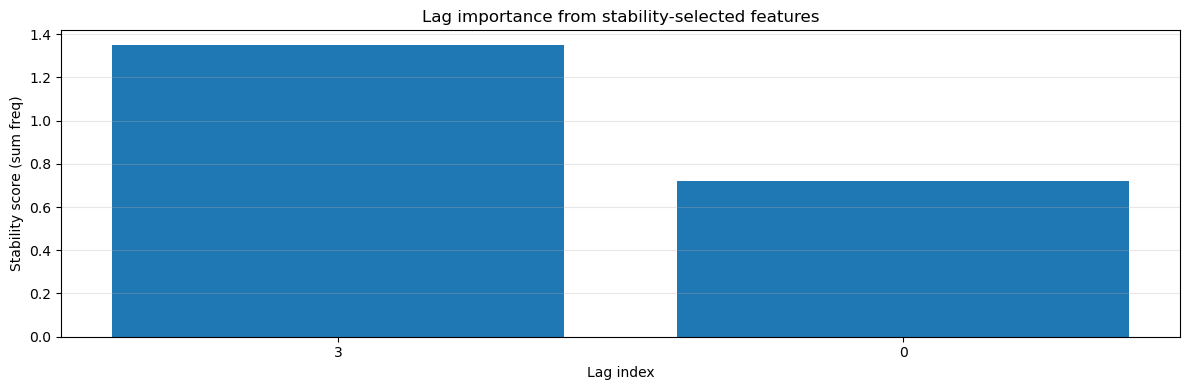


✅ DONE. Outputs in: /data/users/frekle/AMOC_reconstruction/Lat_depth/AMOC_45N_ensmean/IPSL-CM6A-LR/StabilitySelect_L50/


In [12]:
#!/usr/bin/env python3
"""
STABILITY SELECTION OVER ALL FEATURES (var, lon, mode, lag)
----------------------------------------------------------
Works in p >> n regime by using repeated subsampling + Lasso.

Pipeline:
  1) Build FULL X with all lags (0..N_LAGS-1) for VARS×LONS×MODES
  2) Time-split train/test once (last TEST_FRAC held out)
  3) On TRAIN only: run B bootstraps:
       - sample ~FRAC of train years (without replacement)
       - fit StandardScaler + Lasso (alpha chosen from grid by CV on that subsample)
       - record which coefficients are non-zero
  4) Compute selection frequency per feature
  5) Choose selected set (freq >= THRESH or top-N)
  6) Refit Ridge on TRAIN with selected features, evaluate on TEST
  7) Summarize selected features by lag, longitude, variable, mode

Outputs:
  - selection_frequencies.npy + feature_map.npy
  - selected_features.npy
  - summary tables + plots
  - final ridge predictions
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]

N_MODES = 10
N_LAGS  = 50
TEST_FRAC = 0.2

# stability selection
B = 200                 # number of subsamples (increase to 500 if you want)
SUBSAMPLE_FRAC = 0.7    # fraction of TRAIN years used each bootstrap
LASSO_ALPHAS = np.logspace(-4, 1, 12)   # you can widen if needed
CV_FOLDS = 5

# how to pick features after stability selection:
FREQ_THRESH = 0.6       # keep features selected in >=60% of bootstraps
TOP_N = None            # alternatively set TOP_N=200 and set FREQ_THRESH=None

# ridge refit
RIDGE_ALPHAS = [1e-3, 1e-2, 0.1, 1, 10, 100, 1000, 1e4]

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Lat_depth/{TARGET}/{MODEL}/StabilitySelect_L50/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_mean(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))
    if "member" in PC.dims:
        PC = PC.mean("member")
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC

def load_amoc(target):
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[target].squeeze()
    years = extract_years(am["time"])
    am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return am

def build_X_all_lags(pc_dict, years, n_lags):
    years = np.asarray(years).astype(int)
    T = len(years)

    keys_ordered = [(v, l) for v in VARS for l in LON_TAGS]
    pc_np = {k: pc_dict[k].sel(year=years).values for k in pc_dict.keys()}  # (T, n_modes)

    feat_map = []
    for lag in range(n_lags):
        for (var, lon) in keys_ordered:
            nm = pc_np[(var, lon)].shape[1]
            for m in range(nm):
                feat_map.append((var, lon, lag, m))
    feat_map = np.array(feat_map, dtype=object)

    X = []
    time_out = []
    for t in range(n_lags, T):
        feats = []
        for lag in range(n_lags):
            for (var, lon) in keys_ordered:
                feats.extend(pc_np[(var, lon)][t - lag, :].tolist())
        X.append(feats)
        time_out.append(years[t])

    return np.asarray(X, float), feat_map, np.asarray(time_out, int)

def choose_lasso_alpha_cv(X, y, alphas, n_splits=5, seed=0):
    """Pick alpha by CV (on the provided subsample only)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    best = None
    for a in alphas:
        r2s = []
        for tr_idx, va_idx in kf.split(X):
            mdl = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=20000))
            mdl.fit(X[tr_idx], y[tr_idx])
            pred = mdl.predict(X[va_idx])
            r2s.append(r2_score(y[va_idx], pred))
        m = float(np.mean(r2s))
        if best is None or m > best[1]:
            best = (float(a), m)
    return best[0]

def fit_ridge_alpha_scan(Xtr, Ytr, Xte, Yte, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
        mdl.fit(Xtr, Ytr)
        pred = mdl.predict(Xte)
        r2 = float(r2_score(Yte, pred))
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "model": mdl, "pred": pred, "r2": r2}
    return best

# ============================================================
# LOAD PCs
# ============================================================
print("Loading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc_mean(var, lon, N_MODES)
        print(f"  ✓ {var} {lon} PC:", tuple(pc_dict[(var, lon)].shape))

# ============================================================
# LOAD AMOC + COMMON YEARS
# ============================================================
print("Loading AMOC...")
AMOC_da = load_amoc(TARGET)
common_years = AMOC_da["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years).astype(int)
common_years.sort()

AMOC = AMOC_da.sel(year=common_years).values.astype(float).squeeze()
print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

# ============================================================
# BUILD FULL X/Y (ALL 50 LAGS)
# ============================================================
print(f"Building FULL X using ALL lags 0..{N_LAGS-1} ...")
X_full, fmap, time_out = build_X_all_lags(pc_dict, common_years, N_LAGS)
Y_full = AMOC[N_LAGS:]
print("X_full:", X_full.shape, "Y_full:", Y_full.shape)

# Train/test split (time-ordered)
n_train = int((1 - TEST_FRAC) * len(X_full))
Xtr, Xte = X_full[:n_train], X_full[n_train:]
Ytr, Yte = Y_full[:n_train], Y_full[n_train:]
t_test = time_out[n_train:]

# ============================================================
# STABILITY SELECTION (TRAIN ONLY)
# ============================================================
print(f"\nStability selection on TRAIN: B={B}, subsample={SUBSAMPLE_FRAC:.2f}")
rng = np.random.default_rng(0)
ntr = len(Xtr)
m = Xtr.shape[1]

selected_counts = np.zeros(m, dtype=int)

for b in range(B):
    idx = rng.choice(ntr, size=int(SUBSAMPLE_FRAC * ntr), replace=False)
    Xb = Xtr[idx]
    yb = Ytr[idx]

    a_star = choose_lasso_alpha_cv(Xb, yb, LASSO_ALPHAS, n_splits=CV_FOLDS, seed=b)
    mdl = make_pipeline(StandardScaler(), Lasso(alpha=a_star, max_iter=20000))
    mdl.fit(Xb, yb)
    coef = mdl.named_steps["lasso"].coef_
    selected_counts += (np.abs(coef) > 0).astype(int)

    if (b + 1) % 25 == 0:
        print(f"  bootstrap {b+1:3d}/{B}: alpha*={a_star:.3g}, selected={int(np.sum(np.abs(coef)>0))}")

freq = selected_counts / float(B)
np.save(os.path.join(OUTDIR, "selection_frequency.npy"), freq)
np.save(os.path.join(OUTDIR, "feature_map.npy"), fmap)

# choose selected set
if FREQ_THRESH is not None:
    keep_idx = np.where(freq >= FREQ_THRESH)[0]
else:
    keep_idx = np.argsort(freq)[::-1][:int(TOP_N)]

print(f"\nSelected features: {len(keep_idx)} / {m}")
np.save(os.path.join(OUTDIR, "selected_feature_indices.npy"), keep_idx)

# ============================================================
# REFIT RIDGE ON SELECTED FEATURES
# ============================================================
Xtr_sel = Xtr[:, keep_idx]
Xte_sel = Xte[:, keep_idx]

best = fit_ridge_alpha_scan(Xtr_sel, Ytr, Xte_sel, Yte, RIDGE_ALPHAS)
print(f"✓ Ridge refit on selected: alpha={best['alpha']:.4g}  R²={best['r2']:.4f}")

np.save(os.path.join(OUTDIR, "Ytrue_test.npy"), Yte.astype(np.float32))
np.save(os.path.join(OUTDIR, "Ypred_test.npy"), best["pred"].astype(np.float32))
np.save(os.path.join(OUTDIR, "t_test.npy"), t_test.astype(int))

# ============================================================
# SUMMARIES: lag & longitude importance from selection freq
# ============================================================
sel_fmap = fmap[keep_idx]
sel_freq = freq[keep_idx]

# aggregate by lag and by lon
lag_scores = {}
lon_scores = {}
for (var, lon, lag, mode), f in zip(sel_fmap, sel_freq):
    lag = int(lag)
    lag_scores[lag] = lag_scores.get(lag, 0.0) + float(f)
    lon_scores[lon] = lon_scores.get(lon, 0.0) + float(f)

lag_rank = sorted(lag_scores.items(), key=lambda x: x[1], reverse=True)
lon_rank = sorted(lon_scores.items(), key=lambda x: x[1], reverse=True)

print("\nTop lags by stability score:")
for lag, sc in lag_rank[:20]:
    print(f"  lag={lag:2d}  score={sc:.3f}")

print("\nLongitude importance (sum selection freq):")
for lon, sc in lon_rank:
    print(f"  {lon:5s}  score={sc:.3f}")

# plot lag scores
lags = [k for k, _ in lag_rank]
vals = [v for _, v in lag_rank]
plt.figure(figsize=(12,4))
plt.bar([str(l) for l in lags], vals)
plt.xlabel("Lag index")
plt.ylabel("Stability score (sum freq)")
plt.title("Lag importance from stability-selected features")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "lag_importance_stability.png"), dpi=300)
plt.show()

print("\n✅ DONE. Outputs in:", OUTDIR)


In [8]:
#!/usr/bin/env python3
"""
GLOBAL LAG IMPORTANCE FROM EOF PC FILES (all 10 EOF analyses) + ATTRIBUTION + MODES
---------------------------------------------------------------------------------
Reads:
  EOF_latdepth_<var>_<lon>.nc  with:
    PC(member, time, mode)  [mode=10]
  AMOC_<MODEL>.nc with:
    AMOC_26N_ensmean, AMOC_45N_ensmean, etc.

Computes:
  For each (var, lon):
    C(mode, lag) = corr( PC_mode(t-lag), AMOC(t) )
  Then scores each lag using:
    - maxabs: max_m |corr(m,lag)|
    - topk_sum: sum of top-k |corr(m,lag)|

Outputs (in OUTDIR):
  1) *_topN_lags_PER_ANALYSIS.csv
     - includes best_mode (index) and best_mode_abs_corr
  2) *_topN_lags_GLOBAL_ATTRIBUTED.csv
     - global_score per lag
     - attribution: top_lon, top_var, top1_varlon + shares
     - global best_mode per lag (dominant mode across all varlon)
  3) *_lag_by_lon_matrix.csv       (lag × lon)
  4) *_lag_by_varlon_matrix.csv    (lag × varlon)
  5) optional per-analysis heatmaps of C(mode, lag)

This is correlation-based (not regression), so avoids p>>n instability.
"""

import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

MODEL = "IPSL-CM6A-LR"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

TARGET = "AMOC_45N_ensmean"   # or AMOC_26N_ensmean

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

# lag convention
MAX_LAG = 50
USE_PLUS_MINUS = False
if USE_PLUS_MINUS:
    LAGS = np.arange(-MAX_LAG, MAX_LAG + 1, 1, dtype=int)
else:
    LAGS = np.arange(0, MAX_LAG, 1, dtype=int)   # 0..49

TOP_N_LAGS = 15

# scoring method
SCORE_METHOD = "topk_sum"   # "maxabs" or "topk_sum"
TOPK_MODES = 3

# Output directory
OUTDIR = f"/data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/{MODEL}/{TARGET}/"
os.makedirs(OUTDIR, exist_ok=True)

# Optional plotting
MAKE_HEATMAPS = True
HEATMAP_DPI = 200

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction for cftime/numpy datetime."""
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_ensmean(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    # ensmean over members
    if "member" in PC.dims:
        PC = PC.mean("member")

    # (time, mode) -> (year, mode)
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    return PC.astype(float)  # (year, mode)

def load_amoc_1d(target):
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[target].squeeze()

    years = extract_years(am["time"])
    am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    am = am.astype(float).squeeze()

    if am.ndim != 1:
        raise ValueError(f"AMOC target not 1D after squeeze: shape={am.shape}")

    return am  # (year,)

def corr_1d(a, b):
    """Correlation with NaN handling; returns np.nan if not enough data."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def lag_corr_matrix(PC_year_mode, AMOC_year, lags):
    """
    Returns C(mode, lag) with interpretation:
      lag >= 0: PC(t-lag) predicts AMOC(t)
      lag <  0: PC(t+|lag|) predicts AMOC(t) (future predictor; only if USE_PLUS_MINUS=True)
    Inputs are aligned on common years already.
    """
    pc = PC_year_mode.values  # (T, mode)
    y  = AMOC_year.values     # (T,)
    T, M = pc.shape

    C = np.full((M, len(lags)), np.nan, dtype=float)

    for j, lag in enumerate(lags):
        if lag >= 0:
            t_idx = np.arange(lag, T)
            p_idx = t_idx - lag
        else:
            k = -lag
            t_idx = np.arange(0, T - k)
            p_idx = t_idx + k

        yy = y[t_idx]
        for m in range(M):
            pp = pc[p_idx, m]
            C[m, j] = corr_1d(pp, yy)

    return C

def lag_score_from_matrix(C):
    A = np.abs(np.asarray(C))  # (mode, lag)
    if SCORE_METHOD == "maxabs":
        s = np.nanmax(A, axis=0)
        # mode that achieves that max for each lag
        bestm = np.nanargmax(A, axis=0)
        bestv = A[bestm, np.arange(A.shape[1])]
        return s, bestm, bestv
    elif SCORE_METHOD == "topk_sum":
        k = min(TOPK_MODES, A.shape[0])
        # score = sum of top-k across modes
        part = np.partition(A, -k, axis=0)
        topk = part[-k:, :]
        s = np.nansum(topk, axis=0)
        # still report a "dominant mode" as the max |corr| mode (useful for plotting)
        bestm = np.nanargmax(A, axis=0)
        bestv = A[bestm, np.arange(A.shape[1])]
        return s, bestm, bestv
    else:
        raise ValueError(f"Unknown SCORE_METHOD={SCORE_METHOD}")

def save_heatmap(C, lags, title, outpath):
    plt.figure(figsize=(10, 5))
    im = plt.imshow(C, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-1, vmax=1)

    zero_idx = np.where(lags == 0)[0]
    if len(zero_idx) > 0:
        plt.axvline(int(zero_idx[0]), color="k", linestyle="--", linewidth=1)

    plt.colorbar(im, label="Correlation")
    plt.xlabel("Lag (years)")
    plt.ylabel("EOF mode")

    step = max(1, len(lags) // 12)
    plt.xticks(np.arange(0, len(lags), step), lags[::step])

    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=HEATMAP_DPI)
    plt.close()

# ============================================================
# LOAD ALL PCs + AMOC + ALIGN YEARS
# ============================================================

print("Loading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc = load_pc_ensmean(var, lon, N_MODES)
        pc_dict[(var, lon)] = pc
        print(f"  ✓ {var} {lon} PC:", tuple(pc.shape))

print("Loading AMOC...")
AMOC = load_amoc_1d(TARGET)

# common years across all 10
common_years = AMOC["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years).astype(int)
common_years.sort()

print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")
AMOCc = AMOC.sel(year=common_years)

# ============================================================
# PREP MATRICES (lag × lon), (lag × varlon)
# ============================================================

# indices
lag_list = list(LAGS.astype(int))
lon_list = list(LON_TAGS)
varlon_list = [f"{v}_{l}" for v in VARS for l in LON_TAGS]

lag_by_lon = pd.DataFrame(0.0, index=lag_list, columns=lon_list)
lag_by_varlon = pd.DataFrame(0.0, index=lag_list, columns=varlon_list)

# also keep var-only attribution
lag_by_var = {v: np.zeros(len(LAGS), dtype=float) for v in VARS}

# global score (sum across analyses)
global_score = np.zeros(len(LAGS), dtype=float)
global_count = np.zeros(len(LAGS), dtype=float)

# For "global dominant mode per lag":
# we'll accumulate max-|corr| values per (lag, varlon) so we can choose the best mode for each lag globally.
# store per lag: best_abs_corr, best_mode, best_varlon
global_best_abs = np.full(len(LAGS), -np.inf, dtype=float)
global_best_mode = np.full(len(LAGS), -1, dtype=int)         # 1..N_MODES later
global_best_varlon = np.array([""] * len(LAGS), dtype=object)

per_rows = []

# ============================================================
# COMPUTE LAG MATRICES + RANK LAGS
# ============================================================

for var in VARS:
    for lon in LON_TAGS:
        PCc = pc_dict[(var, lon)].sel(year=common_years)

        C = lag_corr_matrix(PCc, AMOCc, LAGS)     # (mode, lag)
        s, bestm0, bestv = lag_score_from_matrix(C)  # score(lag), best mode idx 0-based, best abs corr

        # accumulate global score
        m = np.isfinite(s)
        global_score[m] += s[m]
        global_count[m] += 1

        # fill attribution matrices
        for j, lag in enumerate(LAGS):
            if not np.isfinite(s[j]):
                continue
            lag_int = int(lag)
            lag_by_lon.loc[lag_int, lon] += float(s[j])
            lag_by_varlon.loc[lag_int, f"{var}_{lon}"] += float(s[j])
            lag_by_var[var][j] += float(s[j])

            # update global dominant mode candidate using best abs corr
            # (choose the varlon that has the strongest single-mode abs corr at that lag)
            if np.isfinite(bestv[j]) and float(bestv[j]) > float(global_best_abs[j]):
                global_best_abs[j] = float(bestv[j])
                global_best_mode[j] = int(bestm0[j]) + 1  # 1-based
                global_best_varlon[j] = f"{var}_{lon}"

        # per-analysis top lags
        order = np.argsort(s)[::-1]
        order = order[np.isfinite(s[order])]
        top = order[:TOP_N_LAGS]

        for rank, j in enumerate(top, start=1):
            lag_val = int(LAGS[j])
            bm = int(bestm0[j]) + 1
            bmc = float(bestv[j])

            per_rows.append({
                "model": MODEL,
                "target": TARGET,
                "var": var,
                "lon": lon,
                "varlon": f"{var}_{lon}",
                "rank": rank,
                "lag": lag_val,
                "score": float(s[j]),
                "best_mode": bm,
                "best_mode_abs_corr": bmc,
            })

        print(f"✓ {var} {lon}: top lags = {[int(LAGS[j]) for j in top]}")

        if MAKE_HEATMAPS:
            outpng = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_{var}_{lon}_lagcorr_heatmap.png")
            save_heatmap(C, LAGS, f"{MODEL} {TARGET} — {var} {lon}: PC–AMOC lag corr", outpng)

# ============================================================
# GLOBAL ATTRIBUTED TOP LAGS
# ============================================================

# Pick top lags globally
gorder = np.argsort(global_score)[::-1]
gorder = gorder[np.isfinite(global_score[gorder])]
gtop = gorder[:TOP_N_LAGS]

global_rows = []
for rank, j in enumerate(gtop, start=1):
    lag_val = int(LAGS[j])
    gs = float(global_score[j])

    # attribution: which lon/var/varlon contributes most to *that lag's* global score?
    # Compute shares from matrices
    lon_row = lag_by_lon.loc[lag_val].values
    varlon_row = lag_by_varlon.loc[lag_val].values

    # top lon
    top_lon_idx = int(np.argmax(lon_row)) if len(lon_row) else 0
    top_lon = lag_by_lon.columns[top_lon_idx] if len(lon_row) else ""
    top_lon_share = float(lon_row[top_lon_idx] / (np.sum(lon_row) + 1e-12))

    # top var
    var_scores = {v: float(lag_by_var[v][j]) for v in VARS}
    top_var = max(var_scores, key=var_scores.get) if len(var_scores) else ""
    top_var_share = float(var_scores[top_var] / (sum(var_scores.values()) + 1e-12)) if top_var else np.nan

    # top varlon
    top_varlon_idx = int(np.argmax(varlon_row)) if len(varlon_row) else 0
    top1_varlon = lag_by_varlon.columns[top_varlon_idx] if len(varlon_row) else ""
    top1_share = float(varlon_row[top_varlon_idx] / (np.sum(varlon_row) + 1e-12))

    global_rows.append({
        "model": MODEL,
        "target": TARGET,
        "rank": rank,
        "lag": lag_val,
        "global_score": gs,
        "n_analyses_contributing": int(global_count[j]),
        "top_lon": top_lon,
        "top_lon_share": top_lon_share,
        "top_var": top_var,
        "top_var_share": top_var_share,
        "top1_varlon": top1_varlon,
        "top1_share": top1_share,
        # global dominant mode (based on strongest single-mode abs corr among all varlon at this lag)
        "best_mode": int(global_best_mode[j]) if global_best_mode[j] > 0 else np.nan,
        "best_mode_abs_corr": float(global_best_abs[j]) if np.isfinite(global_best_abs[j]) else np.nan,
        "best_mode_varlon": str(global_best_varlon[j]),
    })

print("\nTop global lags:", [int(LAGS[j]) for j in gtop])

# ============================================================
# SAVE CSVs
# ============================================================

df_per = pd.DataFrame(per_rows).sort_values(["var", "lon", "rank"])
per_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_top{TOP_N_LAGS}_lags_PER_ANALYSIS.csv")
df_per.to_csv(per_csv, index=False)

df_glob = pd.DataFrame(global_rows)
glob_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_top{TOP_N_LAGS}_lags_GLOBAL_ATTRIBUTED.csv")
df_glob.to_csv(glob_csv, index=False)

lon_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_lag_by_lon_matrix.csv")
lag_by_lon.to_csv(lon_csv)

varlon_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_lag_by_varlon_matrix.csv")
lag_by_varlon.to_csv(varlon_csv)

print("\nSaved:")
print("  ", per_csv)
print("  ", glob_csv)
print("  ", lon_csv)
print("  ", varlon_csv)
print("\n✅ DONE.")


Loading EOF PCs...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)
✓ thetao W10p0: top lags = [1, 0, 2, 3, 4, 5, 6, 42, 43, 7, 8, 45, 18, 41, 17]
✓ thetao W20p0: top lags = [20, 17, 3, 11, 18, 16, 4, 2, 21, 19, 26, 25, 10, 12, 28]
✓ thetao W30p0: top lags = [17, 21, 16, 18, 20, 22, 15, 23, 19, 24, 12, 14, 13, 11, 10]
✓ thetao W40p0: top lags = [16, 18, 15, 17, 19, 20, 14, 21, 13, 23, 22, 12, 24, 25, 26]
✓ thetao W60p0: top lags = [1, 0, 5, 2, 4, 6, 3, 7, 15, 14, 8, 18, 17, 21, 22]
✓ so W10p0: top lags = [10, 7, 17, 9, 0, 2, 3, 11, 12, 18, 8, 16, 1, 15, 13]
✓ so W20p0: top lags = [18, 28, 17, 19, 25, 26, 27, 20, 21, 16, 3, 2, 29, 1, 15]
✓ so W30p0: top lags = [16, 7, 13, 15, 14, 0, 4, 12, 5, 17, 11, 

In [9]:
#!/usr/bin/env python3
"""
MAKE FIGURES FROM LAG RANKING CSV FILES (UPDATED)
-------------------------------------------------
Inputs (produced by the UPDATED csv-creator script):
  1) *_topN_lags_GLOBAL_ATTRIBUTED.csv
  2) *_lag_by_lon_matrix.csv
  3) *_lag_by_varlon_matrix.csv
  4) *_topN_lags_PER_ANALYSIS.csv   (optional but recommended)

Outputs (saved in OUTDIR/FIGURES):
  FIG1  Global top-lags barplot (global_score)
  FIG2  Heatmap: lag × longitude importance
  FIG3  Heatmap: lag × (var+lon) importance
  FIG4  "Dominant mode per top lag" (readable): dot plot with varlon labels
  FIG5  Per-analysis summary: which lags repeat across analyses (count/score)
  FIG6  Heatmap: (var+lon) × lag showing only TOP lags per analysis (sparse, readable)

Notes:
  - All figures are correlation-based "importance" (your score), not ridge weights.
  - Indices: lag = PC(t-lag) -> AMOC(t) (when USE_PLUS_MINUS=False in creator script).
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG — EDIT
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

OUTDIR = f"/data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/{MODEL}/{TARGET}/"

# creator script names (default TOP_N_LAGS=15)
TOPN = 15

GLOBAL_FILE = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_top{TOPN}_lags_GLOBAL_ATTRIBUTED.csv")
LON_FILE    = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_lag_by_lon_matrix.csv")
VARLON_FILE = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_lag_by_varlon_matrix.csv")
PER_FILE    = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_top{TOPN}_lags_PER_ANALYSIS.csv")  # optional

FIGDIR = os.path.join(OUTDIR, "FIGURES")
os.makedirs(FIGDIR, exist_ok=True)

print("Saving figures to:", FIGDIR)

# ============================================================
# HELPERS
# ============================================================

def savefig(path, dpi=300):
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)

def safe_read(path, name):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing {name} file: {path}")
    return path

# ============================================================
# LOAD
# ============================================================

safe_read(GLOBAL_FILE, "GLOBAL")
safe_read(LON_FILE, "LON MATRIX")
safe_read(VARLON_FILE, "VARLON MATRIX")

dfG = pd.read_csv(GLOBAL_FILE)
lonmat = pd.read_csv(LON_FILE, index_col=0)
varlonmat = pd.read_csv(VARLON_FILE, index_col=0)

has_per = os.path.exists(PER_FILE)
if has_per:
    dfP = pd.read_csv(PER_FILE)
else:
    dfP = None
    print("NOTE: PER_ANALYSIS file not found, skipping FIG5/FIG6:", PER_FILE)

# Coerce indices
lonmat.index = lonmat.index.astype(int)
varlonmat.index = varlonmat.index.astype(int)
dfG["lag"] = dfG["lag"].astype(int)

# ============================================================
# FIG1 — GLOBAL TOP LAGS (BARPLOT)
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(dfG["lag"], dfG["global_score"])
plt.xlabel("Lag year (PC(t−lag) → AMOC(t))")
plt.ylabel("Global lag importance score")
plt.title(f"{MODEL} {TARGET}: Most important lag years (global)")
plt.grid(axis="y", alpha=0.3)

f1 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG1_global_top_lags.png")
savefig(f1)
plt.close()

# ============================================================
# FIG2 — LAG × LONGITUDE IMPORTANCE HEATMAP
# ============================================================

plt.figure(figsize=(10, 6))
im = plt.imshow(lonmat.values, aspect="auto", origin="lower")
plt.colorbar(im, label="Summed importance score (|corr|-based)")

plt.xticks(np.arange(len(lonmat.columns)), lonmat.columns, rotation=45, ha="right")

# y-axis ticks every 5 lags
yt = np.arange(0, len(lonmat.index), 5)
plt.yticks(yt, lonmat.index.values[yt])

plt.xlabel("Longitude window")
plt.ylabel("Lag year")
plt.title(f"{MODEL} {TARGET}: Lag importance by longitude window")

f2 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG2_lag_by_longitude_heatmap.png")
savefig(f2)
plt.close()

# ============================================================
# FIG3 — LAG × (VAR+LON) IMPORTANCE HEATMAP
# ============================================================

plt.figure(figsize=(12, 6))
im = plt.imshow(varlonmat.values, aspect="auto", origin="lower")
plt.colorbar(im, label="Summed importance score (|corr|-based)")

plt.xticks(np.arange(len(varlonmat.columns)), varlonmat.columns, rotation=45, ha="right")
yt = np.arange(0, len(varlonmat.index), 5)
plt.yticks(yt, varlonmat.index.values[yt])

plt.xlabel("Variable + Longitude group")
plt.ylabel("Lag year")
plt.title(f"{MODEL} {TARGET}: Lag importance by variable and longitude")

f3 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG3_lag_by_varlon_heatmap.png")
savefig(f3)
plt.close()

# ============================================================
# FIG4 — DOMINANT MODE PER TOP LAG (READABLE)
#   Uses GLOBAL_ATTRIBUTED:
#     best_mode, best_mode_abs_corr, best_mode_varlon (or best_mode_varlon)
# ============================================================

# Robust column handling
for col in ["best_mode", "best_mode_abs_corr", "best_mode_varlon"]:
    if col not in dfG.columns:
        print(f"WARNING: {col} missing in GLOBAL file. FIG4 may be incomplete.")

# Sort by lag for readability (or keep rank order if you prefer)
df4 = dfG.sort_values("lag").copy()

plt.figure(figsize=(11, 5))
y = df4["best_mode"].astype(float) if "best_mode" in df4.columns else np.full(len(df4), np.nan)

plt.scatter(df4["lag"], y, s=90)

# label each point with varlon (short)
if "best_mode_varlon" in df4.columns:
    labels = df4["best_mode_varlon"].astype(str).values
else:
    labels = np.array([""] * len(df4))

# add labels with slight vertical jitter to avoid overlap
for i in range(len(df4)):
    lag_i = int(df4["lag"].iloc[i])
    mode_i = y.iloc[i] if hasattr(y, "iloc") else y[i]
    if np.isfinite(mode_i):
        txt = labels[i]
        if txt:
            plt.text(lag_i + 0.4, mode_i + (0.10 if (i % 2 == 0) else -0.18), txt, fontsize=8)

plt.xlabel("Lag year")
plt.ylabel("Dominant EOF mode (1–10)")
plt.yticks(range(1, 11))
plt.title(f"{MODEL} {TARGET}: Dominant EOF mode for each top lag (and where it comes from)")
plt.grid(alpha=0.3)

f4 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG4_dominant_mode_per_top_lag.png")
savefig(f4)
plt.close()

# ============================================================
# FIG5 — WHICH LAGS REPEAT ACROSS ANALYSES? (PER_ANALYSIS)
#   Bar: count of appearances in topN across all (var,lon) analyses
#   Also show mean score for those lags (secondary)
# ============================================================

if has_per:
    dfP["lag"] = dfP["lag"].astype(int)

    # count appearances of each lag among per-analysis topN
    counts = dfP.groupby("lag").size().sort_values(ascending=False)

    # mean score per lag (among appearances)
    mean_score = dfP.groupby("lag")["score"].mean()

    # keep top 20 most frequent lags for readability
    top_lags = counts.index.values[:20]
    cvals = counts.loc[top_lags].values
    svals = mean_score.loc[top_lags].values

    x = np.arange(len(top_lags))

    plt.figure(figsize=(12, 5))
    plt.bar(x, cvals)
    plt.xticks(x, top_lags, rotation=0)
    plt.xlabel("Lag year")
    plt.ylabel(f"Count in top{TOPN} (across {len(dfP['varlon'].unique())} analyses)")
    plt.title(f"{MODEL} {TARGET}: Lags that repeat across analyses (frequency)")
    plt.grid(axis="y", alpha=0.3)

    # annotate with mean score (small text)
    for i in range(len(top_lags)):
        plt.text(x[i], cvals[i] + 0.2, f"{svals[i]:.2f}", ha="center", fontsize=8)

    f5 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG5_repeating_lags_frequency.png")
    savefig(f5)
    plt.close()

# ============================================================
# FIG6 — SPARSE HEATMAP: (VAR+LON) × LAG showing ONLY per-analysis topN scores
#   This is much easier to read than full varlonmat sometimes.
# ============================================================

if has_per:
    # build sparse matrix: rows=varlon, cols=lag
    varlons = sorted(dfP["varlon"].unique().tolist())
    lags = sorted(dfP["lag"].unique().tolist())

    mat = pd.DataFrame(0.0, index=varlons, columns=lags)

    # fill with score where that (varlon, lag) is in topN list (take max score if duplicates)
    for _, r in dfP.iterrows():
        vl = r["varlon"]
        lg = int(r["lag"])
        sc = float(r["score"])
        if sc > mat.loc[vl, lg]:
            mat.loc[vl, lg] = sc

    # reorder columns by global rank if possible (use dfG order), else numerical
    if "rank" in dfG.columns:
        lag_order = dfG.sort_values("rank")["lag"].astype(int).tolist()
        lag_order = [lg for lg in lag_order if lg in mat.columns]
        # append remaining
        rem = [lg for lg in mat.columns if lg not in lag_order]
        lag_order = lag_order + rem
        mat = mat[lag_order]

    plt.figure(figsize=(13, 6))
    im = plt.imshow(mat.values, aspect="auto", origin="lower")
    plt.colorbar(im, label=f"Score (per-analysis top{TOPN} only)")

    plt.yticks(np.arange(len(mat.index)), mat.index)
    plt.xticks(np.arange(len(mat.columns)), mat.columns, rotation=45, ha="right")

    plt.xlabel("Lag year")
    plt.ylabel("Var+Lon group")
    plt.title(f"{MODEL} {TARGET}: Sparse view — which lag years matter for which varlon (top{TOPN} only)")

    f6 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG6_sparse_varlon_vs_lag_topN.png")
    savefig(f6)
    plt.close()

print("\n✅ DONE — All available lag ranking figures created.")
print("FIGDIR:", FIGDIR)


Saving figures to: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/FIGURES
Saved: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG1_global_top_lags.png
Saved: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG2_lag_by_longitude_heatmap.png
Saved: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG3_lag_by_varlon_heatmap.png
Saved: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG4_dominant_mode_per_top_lag.png
Saved: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG5_repeating_lags_frequency.png
Saved: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/F

Reading: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_lag_by_varlon_matrix.csv
Reading: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top15_lags_PER_ANALYSIS.csv


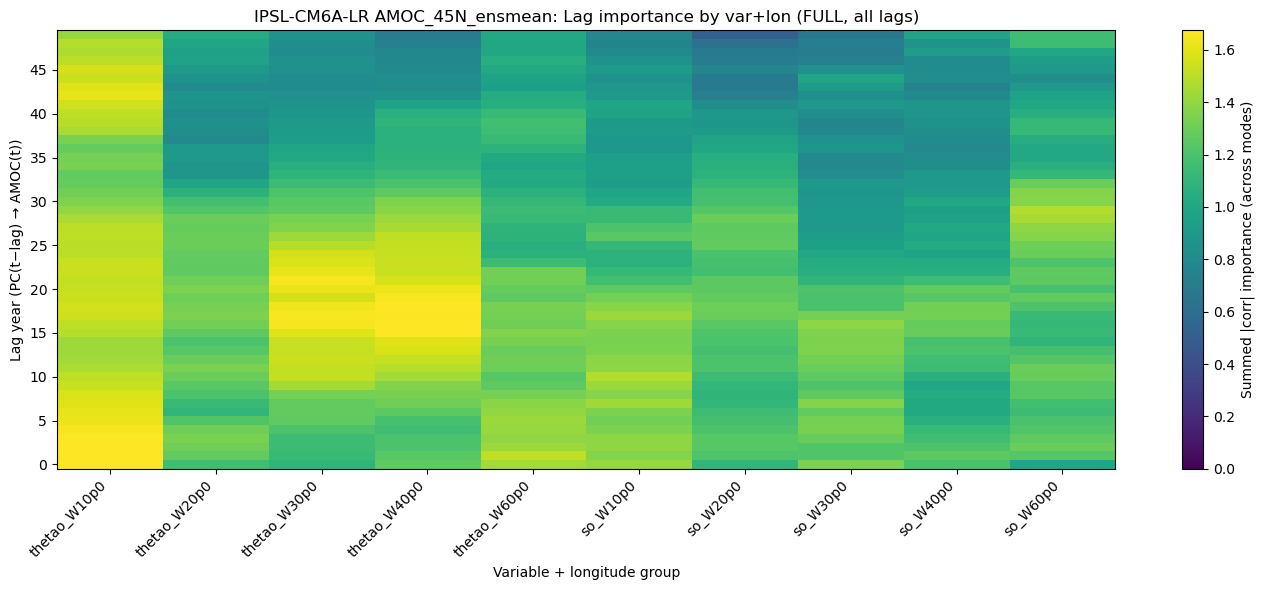

Saved: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG3_varlon_heatmap_FULL.png


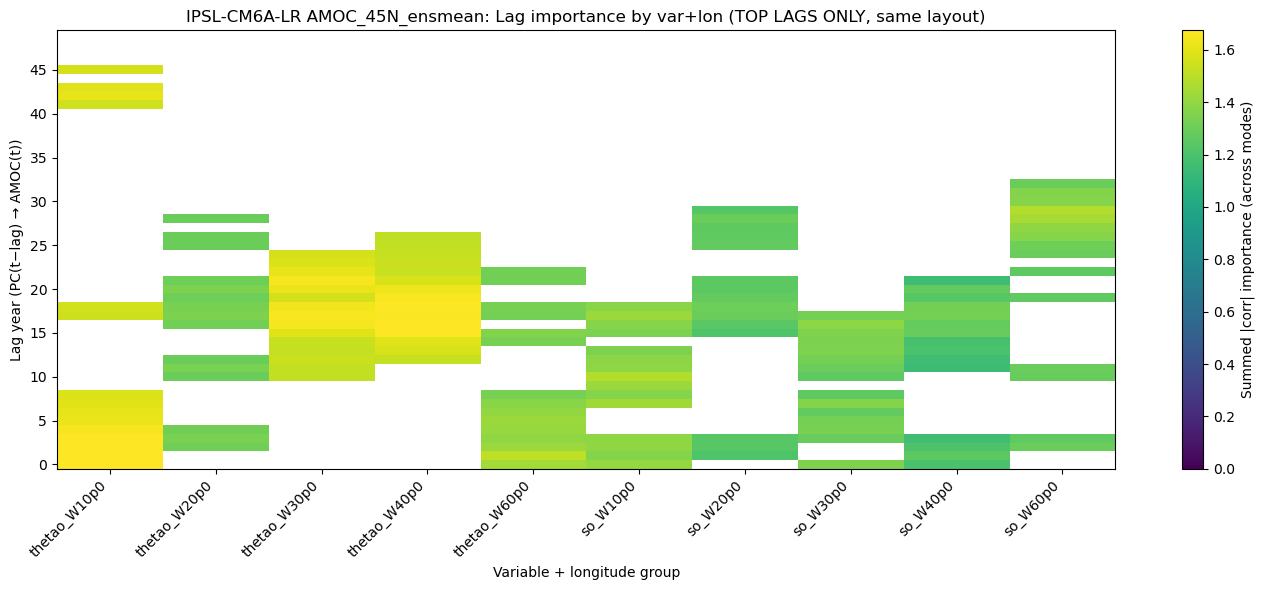

Saved: /data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/IPSL-CM6A-LR/AMOC_45N_ensmean/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG6_varlon_heatmap_TOPLAGS_ONLY.png

✅ DONE — FIG3 and FIG6 now share identical layout & scaling.


In [10]:
#!/usr/bin/env python3
"""
MAKE FIG3 + FIG6 WITH IDENTICAL LAYOUT (VAR+LON × LAG)

FIG3: Full lag_by_varlon_matrix (dense)
FIG6: Same matrix, but only keeps lags that were top-ranked (sparse)

Requires:
  - lag_by_varlon_matrix.csv  (rows=lag, cols=varlon)
  - top15_lags_PER_ANALYSIS.csv (from the PC-lag script)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG — EDIT PATHS
# ============================================================
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

OUTDIR = f"/data/users/frekle/AMOC_analysis/TopLagYears_fromPCs/{MODEL}/{TARGET}/"
FIGDIR = os.path.join(OUTDIR, "FIGURES")
os.makedirs(FIGDIR, exist_ok=True)

VARLON_FILE = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_lag_by_varlon_matrix.csv")
PER_FILE    = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_top15_lags_PER_ANALYSIS.csv")

# lag axis (must match your lag script)
MAX_LAG = 50
LAGS = np.arange(0, MAX_LAG, dtype=int)

# Plot formatting (shared)
FIGSIZE = (14, 6)
YTICK_STEP = 5
XTICK_ROT = 45

print("Reading:", VARLON_FILE)
mat_full = pd.read_csv(VARLON_FILE, index_col=0)

# Ensure lag index is int and reindex to 0..49
mat_full.index = mat_full.index.astype(int)
mat_full = mat_full.reindex(LAGS)

# Keep column order fixed
varlon_cols = list(mat_full.columns)

# ------------------------------------------------------------
# Build sparse matrix (FIG6) with SAME shape/layout as FIG3
# ------------------------------------------------------------
print("Reading:", PER_FILE)
df_per = pd.read_csv(PER_FILE)

# Create a varlon label that matches matrix columns:
# (expects columns "var" and "lon" in PER csv)
if not {"var", "lon", "lag"}.issubset(df_per.columns):
    raise ValueError("PER_ANALYSIS csv must contain columns: var, lon, lag")

df_per["varlon"] = df_per["var"].astype(str) + "_" + df_per["lon"].astype(str)

# Only keep varlon groups that exist in the full matrix
df_per = df_per[df_per["varlon"].isin(varlon_cols)].copy()

# Mark the (lag, varlon) cells to keep
keep_pairs = set(zip(df_per["lag"].astype(int).values, df_per["varlon"].values))

# Build sparse copy: set everything not in keep_pairs to NaN
mat_sparse = mat_full.copy()
for lag in mat_sparse.index:
    for col in mat_sparse.columns:
        if (int(lag), col) not in keep_pairs:
            mat_sparse.loc[lag, col] = np.nan  # sparse

# ------------------------------------------------------------
# Shared color scaling (so the two plots compare properly)
# ------------------------------------------------------------
# Use FULL matrix to set scale; ignore NaNs
vmax = np.nanpercentile(mat_full.values, 99)  # robust upper limit
vmin = 0.0  # scores are nonnegative (sum of |corr|)

def plot_varlon_heatmap(mat, title, outfile):
    plt.figure(figsize=FIGSIZE)
    im = plt.imshow(
        mat.values,
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(im, label="Summed |corr| importance (across modes)")

    # x ticks = varlon columns
    plt.xticks(
        np.arange(len(mat.columns)),
        mat.columns,
        rotation=XTICK_ROT,
        ha="right",
    )

    # y ticks = lag years
    yticks = np.arange(0, len(mat.index), YTICK_STEP)
    plt.yticks(yticks, mat.index.values[::YTICK_STEP])

    plt.xlabel("Variable + longitude group")
    plt.ylabel("Lag year (PC(t−lag) → AMOC(t))")
    plt.title(title)

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()
    print("Saved:", outfile)

# ============================================================
# FIG3 — FULL varlon heatmap (dense)
# ============================================================
f3 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG3_varlon_heatmap_FULL.png")
plot_varlon_heatmap(
    mat_full,
    f"{MODEL} {TARGET}: Lag importance by var+lon (FULL, all lags)",
    f3
)

# ============================================================
# FIG6 — SPARSE varlon heatmap (top-lags only, same layout)
# ============================================================
f6 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG6_varlon_heatmap_TOPLAGS_ONLY.png")
plot_varlon_heatmap(
    mat_sparse,
    f"{MODEL} {TARGET}: Lag importance by var+lon (TOP LAGS ONLY, same layout)",
    f6
)

print("\n✅ DONE — FIG3 and FIG6 now share identical layout & scaling.")


### Top 50 features

In [3]:
#!/usr/bin/env python3
"""
GLOBAL TOP MODE–LAG FEATURES FROM EOF PC FILES (lat–depth sections)
------------------------------------------------------------------
Builds PC–AMOC lag-correlation matrices from your EOF_latdepth files:

  EOF_latdepth_<var>_<lon>.nc:
    PC(member, time, mode)

Then flattens into features (var, lon, mode, lag) ranked by |corr|.

NEW / UPDATED:
  ✅ Adds MAX_LAG_ALLOWED to restrict which lags are allowed in the ranking
  ✅ Saves BOTH:
      (1) topN from ALL lags (0..MAX_LAG_TOTAL-1)
      (2) topN from RESTRICTED lags (0..MAX_LAG_ALLOWED)
  ✅ Also saves a per-(var,lon) summary of the best lag+mode (optional)

Outputs (in OUTDIR):
  - *_top50_mode_lag_features_ALLLAGS.csv
  - *_top50_mode_lag_features_LAGMAX<MAX_LAG_ALLOWED>.csv
  - *_top50_mode_lag_features_ALLLAGS.npy
  - *_top50_mode_lag_features_LAGMAX<...>.npy

Notes:
  - This is correlation-based feature ranking (not regression),
    so it avoids the p>>n instability you saw with ridge/lasso.
  - Lag convention: lag >= 0 means PC(t-lag) vs AMOC(t).
"""

import os
import numpy as np
import xarray as xr
import pandas as pd

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"   # or "AMOC_26N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Total lag range computed (0..MAX_LAG_TOTAL-1)
MAX_LAG_TOTAL = 50

# ✅ Restrict ranking to lags <= MAX_LAG_ALLOWED (set None to disable)
MAX_LAG_ALLOWED = 25   # e.g. 15, 20, 25, 30; must be < MAX_LAG_TOTAL

TOP_N_FEATURES = 50

OUTDIR = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction for cftime/numpy datetime."""
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_ensmean(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    # ensemble mean over member
    if "member" in PC.dims:
        PC = PC.mean("member")

    # (time, mode) -> (year, mode)
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    return PC.astype(float)  # (year, mode)

def load_amoc_1d(target):
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[target].squeeze()

    years = extract_years(am["time"])
    am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    am = am.astype(float)

    am = am.squeeze()
    if am.ndim != 1:
        raise ValueError(f"AMOC target not 1D after squeeze: shape={am.shape}")

    return am  # (year,)

def corr_1d(a, b):
    """Correlation with NaN handling; returns np.nan if not enough data."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def lag_corr_matrix(PC_year_mode, AMOC_year, lags):
    """
    Returns C(mode, lag) where lag >= 0 means:
      PC(t-lag) correlated with AMOC(t)
    Inputs must be aligned on same years beforehand.
    """
    pc = PC_year_mode.values  # (T, mode)
    y  = AMOC_year.values     # (T,)
    T, M = pc.shape
    C = np.full((M, len(lags)), np.nan, dtype=float)

    for j, lag in enumerate(lags):
        lag = int(lag)
        if lag < 0:
            raise ValueError("This script expects non-negative lags only.")
        if lag >= T:
            continue

        t_idx = np.arange(lag, T)   # target indices
        p_idx = t_idx - lag         # predictor indices

        yy = y[t_idx]
        for m in range(M):
            pp = pc[p_idx, m]
            C[m, j] = corr_1d(pp, yy)

    return C

# ============================================================
# LOAD PCs + AMOC + ALIGN YEARS
# ============================================================

print("Loading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc = load_pc_ensmean(var, lon, N_MODES)
        pc_dict[(var, lon)] = pc
        print(f"  ✓ {var} {lon} PC: {tuple(pc.shape)}")

print("Loading AMOC...")
AMOC = load_amoc_1d(TARGET)

# Common years across ALL 10 analyses
common_years = AMOC["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years).astype(int)
common_years.sort()

AMOCc = AMOC.sel(year=common_years)

print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

# Lags 0..MAX_LAG_TOTAL-1
LAGS = np.arange(0, MAX_LAG_TOTAL, 1, dtype=int)

# ============================================================
# COMPUTE CORR MATRICES + BUILD FEATURE TABLE
# ============================================================

feature_rows = []
best_rows = []  # optional: best (mode,lag) per (var,lon)

for var in VARS:
    for lon in LON_TAGS:
        PCc = pc_dict[(var, lon)].sel(year=common_years)

        C = lag_corr_matrix(PCc, AMOCc, LAGS)  # (mode, lag)

        # optional summary: best mode+lag for this (var,lon)
        absC = np.abs(C)
        flat_idx = np.nanargmax(absC)
        best_m, best_j = np.unravel_index(flat_idx, absC.shape)
        best_rows.append({
            "model": MODEL,
            "target": TARGET,
            "var": var,
            "lon": lon,
            "best_mode": int(best_m + 1),     # 1-based for readability
            "best_lag": int(LAGS[best_j]),
            "best_corr": float(C[best_m, best_j]),
            "best_abs_corr": float(absC[best_m, best_j]),
        })

        # feature list (var,lon,mode,lag)
        for m in range(N_MODES):
            for j, lag in enumerate(LAGS):
                corr = C[m, j]
                if not np.isfinite(corr):
                    continue
                feature_rows.append({
                    "model": MODEL,
                    "target": TARGET,
                    "var": var,
                    "lon": lon,
                    "mode": int(m + 1),     # 1-based
                    "lag": int(lag),
                    "corr": float(corr),
                    "abs_corr": float(abs(corr)),
                })

print(f"Built feature table: {len(feature_rows)} rows")

df_all = pd.DataFrame(feature_rows)

# ============================================================
# SAVE TOP-N (ALL LAGS)
# ============================================================

df_all_sorted = df_all.sort_values("abs_corr", ascending=False).reset_index(drop=True)
df_top_all = df_all_sorted.head(TOP_N_FEATURES)

out_csv_all = os.path.join(
    OUTDIR, f"{MODEL}_{TARGET}_top{TOP_N_FEATURES}_mode_lag_features_ALLLAGS.csv"
)
out_npy_all = os.path.join(
    OUTDIR, f"{MODEL}_{TARGET}_top{TOP_N_FEATURES}_mode_lag_features_ALLLAGS.npy"
)

df_top_all.to_csv(out_csv_all, index=False)
np.save(out_npy_all, df_top_all.to_records(index=False))

print("Saved ALL-LAGS Top-N:")
print("  csv:", out_csv_all)
print("  npy:", out_npy_all)

# ============================================================
# SAVE TOP-N (RESTRICTED LAGS)
# ============================================================

if MAX_LAG_ALLOWED is not None:
    if MAX_LAG_ALLOWED >= MAX_LAG_TOTAL:
        raise ValueError("MAX_LAG_ALLOWED must be < MAX_LAG_TOTAL")
    df_restrict = df_all[df_all["lag"] <= int(MAX_LAG_ALLOWED)].copy()
    df_restrict = df_restrict.sort_values("abs_corr", ascending=False).reset_index(drop=True)

    df_top_restrict = df_restrict.head(TOP_N_FEATURES)

    out_csv_re = os.path.join(
        OUTDIR, f"{MODEL}_{TARGET}_top{TOP_N_FEATURES}_mode_lag_features_LAGMAX{MAX_LAG_ALLOWED}.csv"
    )
    out_npy_re = os.path.join(
        OUTDIR, f"{MODEL}_{TARGET}_top{TOP_N_FEATURES}_mode_lag_features_LAGMAX{MAX_LAG_ALLOWED}.npy"
    )

    df_top_restrict.to_csv(out_csv_re, index=False)
    np.save(out_npy_re, df_top_restrict.to_records(index=False))

    print(f"\nSaved RESTRICTED-LAGS Top-N (lag<= {MAX_LAG_ALLOWED}):")
    print("  csv:", out_csv_re)
    print("  npy:", out_npy_re)
    print("  remaining rows after cutoff:", len(df_restrict))

# ============================================================
# SAVE PER-(VAR,LON) BEST SUMMARY
# ============================================================

df_best = pd.DataFrame(best_rows).sort_values(["var", "lon"]).reset_index(drop=True)
out_best = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_best_mode_lag_per_varlon.csv")
df_best.to_csv(out_best, index=False)

print("\nSaved per-(var,lon) best summary:")
print("  csv:", out_best)

print("\n✅ DONE.")


Loading EOF PCs...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)
Built feature table: 5000 rows
Saved ALL-LAGS Top-N:
  csv: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top50_mode_lag_features_ALLLAGS.csv
  npy: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top50_mode_lag_features_ALLLAGS.npy

Saved RESTRICTED-LAGS Top-N (lag<= 25):
  csv: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top50_mode_lag_features_LAGMAX25.csv
  npy: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_

Loaded Top-50 CSV: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top50_mode_lag_features_LAGMAX25.csv
          model            target     var    lon  mode  lag      corr  \
0  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   16 -0.693010   
1  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   15 -0.677937   
2  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   17 -0.674132   
3  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   12 -0.666395   
4  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W40p0     8   18 -0.665700   

   abs_corr  
0  0.693010  
1  0.677937  
2  0.674132  
3  0.666395  
4  0.665700  

Loading EOF PCs...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)

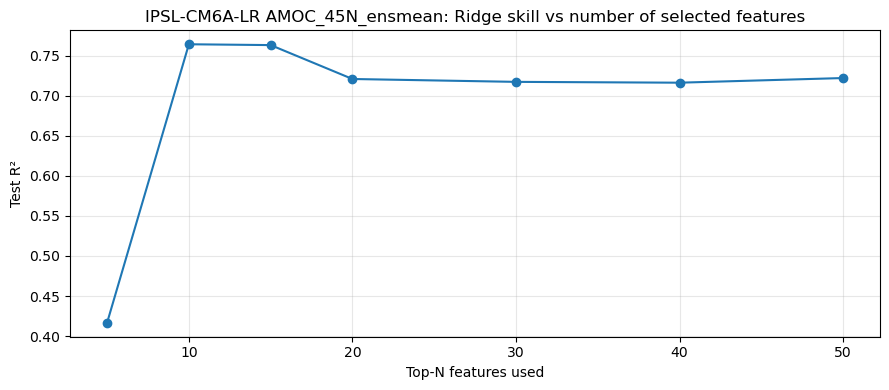

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG1_R2_vs_N.png


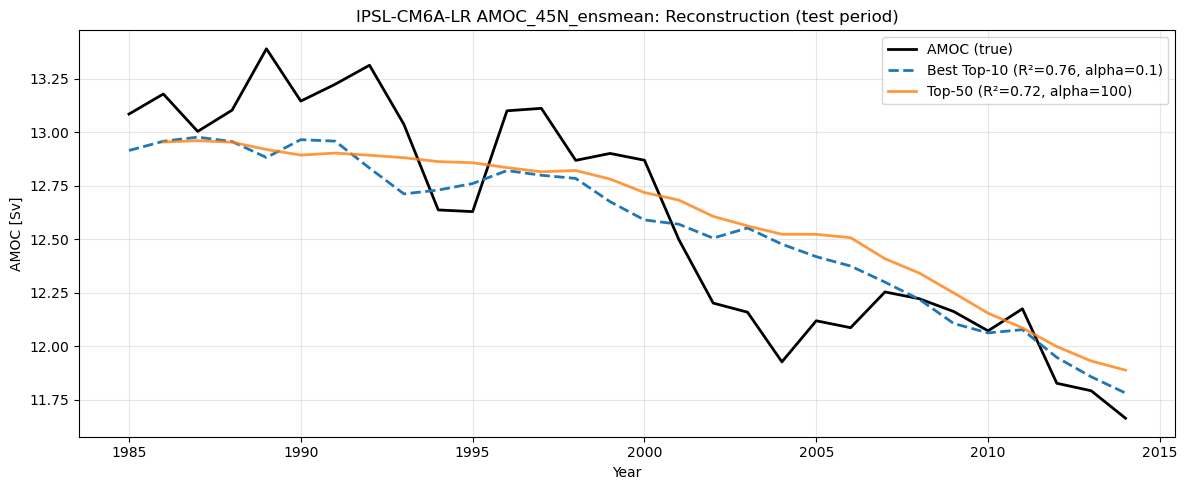

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG2_timeseries_bestN_vs_top50.png


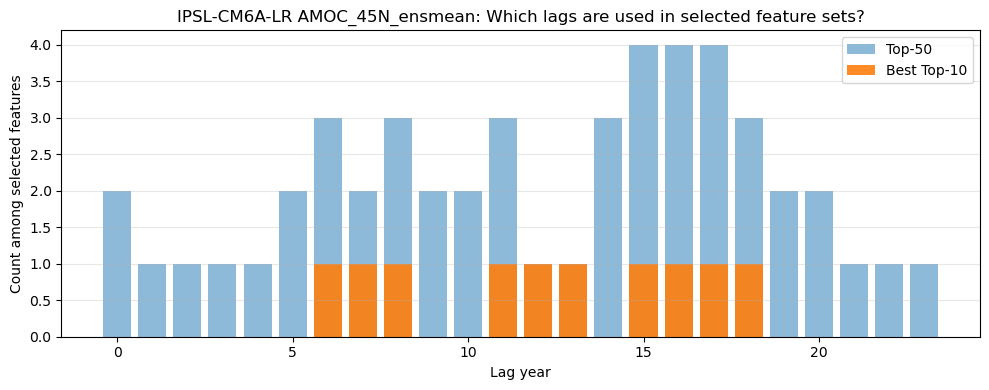

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG3_lag_hist_selected_features.png
Saved best feature list: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP/IPSL-CM6A-LR_AMOC_45N_ensmean_BEST_top10_features.csv

✅ DONE.
OUTDIR: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP


In [4]:
#!/usr/bin/env python3
"""
RIDGE RECONSTRUCTION — PROGRESSIVE TOP-N FEATURE SWEEP
-----------------------------------------------------

Input:
  CSV from previous step:
    <MODEL>_<TARGET>_top50_mode_lag_features.csv
  Contains rows: var, lon, mode, lag, corr, abs_corr

What this script does:
  For N in N_LIST:
    - build X using only the Top-N (var,lon,mode,lag) features
    - fit Ridge (StandardScaler + Ridge) scanning alphas
    - evaluate on test (time-split)
  Also fits:
    - "Top-50 model" (N=50) explicitly (same as last point)

Outputs:
  - metrics csv (N, n_features, best_alpha, R2, corr, var_ratio, mae, rmse)
  - figure: R² vs N
  - figure: time series for best N and Top-50
  - figure: lag histogram for best N and Top-50

Notes:
  - Uses only past lags: PC(t-lag) -> AMOC(t)
  - Keeps temporal causality.
"""

import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

VARS     = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]

N_MODES = 10
TEST_FRAC = 0.2

# Ridge alpha scan (same spirit as your earlier runs)
RIDGE_ALPHAS = [0.1, 1, 10, 100, 1000, 1e4, 1e5]

# Progressive sweep list
N_LIST = [5, 10, 15, 20, 30, 40, 50]

# Input Top-50 CSV
IN_DIR = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/"
TOP50_CSV = os.path.join(IN_DIR, f"{MODEL}_{TARGET}_top50_mode_lag_features_LAGMAX25.csv")

# Output directory
OUTDIR = os.path.join(IN_DIR, "RIDGE_TOPN_SWEEP")
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_ensmean(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def load_amoc_1d():
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[TARGET].squeeze()
    years = extract_years(am["time"])
    am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    am = am.astype(float).squeeze()
    if am.ndim != 1:
        raise ValueError(f"AMOC not 1D after squeeze: shape={am.shape}")
    return am  # (year,)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return r2, r, var_ratio, mae, rmse

def fit_ridge_alpha_scan(Xtr, Ytr, Xte, Yte, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
        mdl.fit(Xtr, Ytr)
        pred = mdl.predict(Xte)
        r2 = float(r2_score(Yte, pred))
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "model": mdl, "pred": pred, "r2": r2}
    best["pred_tr"] = best["model"].predict(Xtr)
    return best

def build_X_from_feature_list(pc_dict, years, features):
    """
    Build X and Y alignment for features defined as:
      features: list of dicts/rows with (var, lon, mode, lag)
    Convention:
      x_i(t) = PC_mode(t - lag)
      y(t)   = AMOC(t)

    Output:
      X: (T_eff, n_features)
      time_out: years used for y
      max_lag: max lag in list
    """
    years = np.asarray(years).astype(int)
    T = len(years)

    # access arrays
    pc_np = {k: v.sel(year=years).values for k, v in pc_dict.items()}  # (T, mode)

    max_lag = int(np.max([int(f["lag"]) for f in features])) if len(features) else 0
    t_idx = np.arange(max_lag, T)  # y indices
    time_out = years[t_idx]

    X = np.zeros((len(t_idx), len(features)), dtype=float)

    for j, f in enumerate(features):
        var = str(f["var"])
        lon = str(f["lon"])
        mode = int(f["mode"]) - 1
        lag  = int(f["lag"])

        # predictor index = t - lag
        p_idx = t_idx - lag
        X[:, j] = pc_np[(var, lon)][p_idx, mode]

    return X, time_out, max_lag

# ============================================================
# LOAD Top-50 LIST
# ============================================================

if not os.path.exists(TOP50_CSV):
    raise FileNotFoundError(f"Missing Top-50 CSV: {TOP50_CSV}")

df50 = pd.read_csv(TOP50_CSV)

# Ensure correct ordering: highest abs_corr first
df50 = df50.sort_values("abs_corr", ascending=False).reset_index(drop=True)

print("Loaded Top-50 CSV:", TOP50_CSV)
print(df50.head(5))

# ============================================================
# LOAD PCs + AMOC + COMMON YEARS
# ============================================================

print("\nLoading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc_ensmean(var, lon, N_MODES)
        print(f"  ✓ {var} {lon} PC:", tuple(pc_dict[(var, lon)].shape))

print("Loading AMOC...")
AMOC = load_amoc_1d()

common_years = AMOC["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.sort(common_years.astype(int))

AMOCc = AMOC.sel(year=common_years).values.astype(float).squeeze()
print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

# ============================================================
# SWEEP Top-N
# ============================================================

rows = []
pred_cache = {}  # store predictions for plotting later

for N in N_LIST:
    N = int(min(N, len(df50)))
    feats = df50.head(N).to_dict("records")

    X, t_out, max_lag = build_X_from_feature_list(pc_dict, common_years, feats)
    Y = AMOCc[max_lag:]  # aligned with t_out

    # train/test split (time ordered)
    n_train = int((1 - TEST_FRAC) * len(X))
    Xtr, Xte = X[:n_train], X[n_train:]
    Ytr, Yte = Y[:n_train], Y[n_train:]
    t_test = t_out[n_train:]

    fit = fit_ridge_alpha_scan(Xtr, Ytr, Xte, Yte, RIDGE_ALPHAS)
    met = metrics(Yte, fit["pred"])

    rows.append([N, X.shape[1], max_lag, fit["alpha"], *met])
    print(f"N={N:2d} feats={X.shape[1]:3d} max_lag={max_lag:2d}  alpha={fit['alpha']:<8g}  R²={met[0]: .4f}  corr={met[1]: .4f}  var={met[2]: .3f}")

    pred_cache[N] = {
        "t_test": t_test,
        "Yte": Yte,
        "pred": fit["pred"],
        "alpha": fit["alpha"],
        "metrics": met,
        "features": feats
    }

sweep = pd.DataFrame(
    rows,
    columns=["N_features_used", "n_predictors", "max_lag_used", "best_alpha", "R2", "corr", "var_ratio", "mae", "rmse"]
)

sweep_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_ridge_topN_sweep_metrics.csv")
sweep.to_csv(sweep_csv, index=False)
print("\nSaved sweep metrics:", sweep_csv)

# Identify best N by R²
best_row = sweep.iloc[int(np.argmax(sweep["R2"].values))]
bestN = int(best_row["N_features_used"])
print(f"\n✓ Best N by test R²: N={bestN} with R²={float(best_row['R2']):.4f}")

# ============================================================
# FIGURE 1 — R² vs N
# ============================================================

plt.figure(figsize=(9,4))
plt.plot(sweep["N_features_used"], sweep["R2"], marker="o")
plt.xlabel("Top-N features used")
plt.ylabel("Test R²")
plt.title(f"{MODEL} {TARGET}: Ridge skill vs number of selected features")
plt.grid(alpha=0.3)
plt.tight_layout()
f1 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_FIG1_R2_vs_N.png")
plt.savefig(f1, dpi=300)
plt.show()
print("Saved:", f1)

# ============================================================
# FIGURE 2 — Timeseries: truth vs bestN vs N=50
# ============================================================

# bestN plot
b = pred_cache[bestN]
f = pred_cache[max(N_LIST)]  # typically 50

plt.figure(figsize=(12,5))
plt.plot(b["t_test"], b["Yte"], lw=2, color="black", label="AMOC (true)")
plt.plot(b["t_test"], b["pred"], lw=2, linestyle="--",
         label=f"Best Top-{bestN} (R²={b['metrics'][0]:.2f}, alpha={b['alpha']:.3g})")
plt.plot(f["t_test"], f["pred"], lw=2, alpha=0.8,
         label=f"Top-50 (R²={f['metrics'][0]:.2f}, alpha={f['alpha']:.3g})")
plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} {TARGET}: Reconstruction (test period)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f2 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_FIG2_timeseries_bestN_vs_top50.png")
plt.savefig(f2, dpi=300)
plt.show()
print("Saved:", f2)

# ============================================================
# FIGURE 3 — Lag distribution inside selected features (bestN and Top-50)
# ============================================================

def lag_hist(features):
    lags = [int(ff["lag"]) for ff in features]
    vals, counts = np.unique(lags, return_counts=True)
    return vals, counts

vals_b, cnt_b = lag_hist(b["features"])
vals_f, cnt_f = lag_hist(f["features"])

plt.figure(figsize=(10,4))
plt.bar(vals_f, cnt_f, alpha=0.5, label="Top-50")
plt.bar(vals_b, cnt_b, alpha=0.9, label=f"Best Top-{bestN}")
plt.xlabel("Lag year")
plt.ylabel("Count among selected features")
plt.title(f"{MODEL} {TARGET}: Which lags are used in selected feature sets?")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
f3 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_FIG3_lag_hist_selected_features.png")
plt.savefig(f3, dpi=300)
plt.show()
print("Saved:", f3)

# ============================================================
# SAVE: best feature list (so you can reuse it directly)
# ============================================================

best_feats_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_BEST_top{bestN}_features.csv")
pd.DataFrame(b["features"]).to_csv(best_feats_csv, index=False)
print("Saved best feature list:", best_feats_csv)

print("\n✅ DONE.")
print("OUTDIR:", OUTDIR)


In [2]:
#!/usr/bin/env python3
"""
RIDGE SWEEP USING TOP MODE–LAG FEATURES (with lag-window expansion)
------------------------------------------------------------------
Reads Top-N features from:
  *_top50_mode_lag_features_*.csv   (columns: var, lon, mode, lag, abs_corr, ...)

Then for each N in N_LIST:
  - take the top-N rows
  - expand each (var,lon,mode,lag) into a lag window [lag-W ... lag+W]
  - (optional) cap number of unique lags per (var,lon,mode)
  - build X from those selected (var,lon,mode,lag) features
  - fit ridge (alpha scan) on TRAIN, evaluate on TEST

This usually performs much closer to your lag-block/group-sweep script.
"""

import os
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

TOPCSV = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/" \
         f"{MODEL}_{TARGET}_top50_mode_lag_features_LAGMAX25.csv"

TEST_FRAC = 0.2
RIDGE_ALPHAS = [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000, 1e4, 1e5]

# Sweep how many “seed” features we take from CSV
N_LIST = [5, 10, 15, 20, 30, 40, 50]

# ✅ Key upgrade: expand each selected lag into a window lag±W
LAG_WINDOW = 2   # e.g. 0,1,2,3
# If your CSV is LAGMAX25, keep features within [0..25]
MAX_LAG_ALLOWED = 25

# ✅ Optional redundancy control:
# max number of unique lags allowed per (var,lon,mode) AFTER expansion
CAP_LAGS_PER_GROUP = None   # set None to disable

OUTDIR = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/RIDGE_TOPN_SWEEP_WINDOW/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))
    if "member" in PC.dims:
        PC = PC.mean("member")
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def fit_ridge_alpha_scan(X_train, Y_train, X_test, Y_test, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(a)))
        mdl.fit(X_train, Y_train)
        pred = mdl.predict(X_test)
        r2 = float(r2_score(Y_test, pred))
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "model": mdl, "pred": pred, "r2": r2}
    return best

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio

def build_selected_feature_set(df_top):
    """
    From top rows (var,lon,mode,lag) build a set of features:
      (var, lon, mode0based, lag)
    applying lag-window expansion + optional cap per group.
    """
    # seed list
    seeds = []
    for _, row in df_top.iterrows():
        var = str(row["var"])
        lon = str(row["lon"])
        mode1 = int(row["mode"])          # 1-based in CSV
        lag = int(row["lag"])
        seeds.append((var, lon, mode1 - 1, lag))

    # expand lag window
    expanded = []
    for (var, lon, m, lag) in seeds:
        for L in range(lag - LAG_WINDOW, lag + LAG_WINDOW + 1):
            if L < 0 or (MAX_LAG_ALLOWED is not None and L > MAX_LAG_ALLOWED):
                continue
            expanded.append((var, lon, m, int(L)))

    # optional cap lags per (var,lon,mode)
    if CAP_LAGS_PER_GROUP is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])  # (var,lon,mode)
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(CAP_LAGS_PER_GROUP):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    # unique
    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

def build_X_from_features(pc_np, years, feats):
    """
    years: array length T (common years)
    feats: list of (var, lon, mode0based, lag) where lag>=0 means use PC[t-lag] to predict Y[t]
    Returns X (T - max_lag, n_features), time_out, max_lag
    """
    years = np.asarray(years).astype(int)
    T = len(years)

    max_lag = max([lag for (_,_,_,lag) in feats]) if len(feats) else 0
    rows = []
    t_out = []

    for t in range(max_lag, T):
        xrow = []
        for (var, lon, m, lag) in feats:
            xrow.append(pc_np[(var, lon)][t - lag, m])
        rows.append(xrow)
        t_out.append(years[t])

    return np.asarray(rows, float), np.asarray(t_out, int), int(max_lag)

# ============================================================
# LOAD CSV
# ============================================================

df_rank = pd.read_csv(TOPCSV)
print("Loaded Top-50 CSV:", TOPCSV)
print(df_rank.head())

# ============================================================
# LOAD PCs
# ============================================================

print("\nLoading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc(var, lon, N_MODES)
        print(f"  ✓ {var} {lon} PC:", tuple(pc_dict[(var, lon)].shape))

# ============================================================
# LOAD AMOC + COMMON YEARS
# ============================================================

print("Loading AMOC...")
dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET].squeeze()
AMOC_years = extract_years(AMOC_da["time"])
AMOC_da = AMOC_da.assign_coords(year=("time", AMOC_years)).swap_dims({"time": "year"}).drop_vars("time")

common_years = AMOC_da["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years).astype(int)
common_years.sort()

AMOC = AMOC_da.sel(year=common_years).values.squeeze()
print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

# prefetch PCs as numpy on common years
pc_np = {k: v.sel(year=common_years).values for k, v in pc_dict.items()}  # (T, mode)

# ============================================================
# SWEEP N
# ============================================================

rows = []
best = None

for N in N_LIST:
    df_top = df_rank.head(N)
    feats = build_selected_feature_set(df_top)

    X, t_out, max_lag = build_X_from_features(pc_np, common_years, feats)
    Y = AMOC[max_lag:]

    n_train = int((1 - TEST_FRAC) * len(X))
    Xtr, Xte = X[:n_train], X[n_train:]
    Ytr, Yte = Y[:n_train], Y[n_train:]

    res = fit_ridge_alpha_scan(Xtr, Ytr, Xte, Yte, RIDGE_ALPHAS)
    met = metrics(Yte, res["pred"])

    rows.append([N, len(feats), max_lag, res["alpha"], met[0], met[1], met[2]])

    print(f"N={N:2d} seeds  feats={len(feats):4d}  max_lag={max_lag:2d}  "
          f"alpha={res['alpha']:<8g}  R²={met[0]: .4f}  corr={met[1]: .4f}  var={met[2]: .3f}")

    if best is None or met[0] > best["r2"]:
        best = {"N": N, "feats": feats, "nfeats": len(feats), "max_lag": max_lag,
                "alpha": res["alpha"], "r2": met[0], "corr": met[1], "var": met[2]}

out_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_ridge_topN_sweep_window_metrics.csv")
pd.DataFrame(rows, columns=["N_seeds", "n_features_after_window", "max_lag_used", "alpha", "r2", "corr", "var_ratio"]).to_csv(out_csv, index=False)
print("\nSaved sweep metrics:", out_csv)

print(f"\n✓ Best by test R²: N={best['N']} seeds  -> {best['nfeats']} feats, max_lag={best['max_lag']}, "
      f"alpha={best['alpha']}  R²={best['r2']:.4f}  corr={best['corr']:.4f}  var={best['var']:.3f}")

# save best feature list
best_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_BEST_features_window.csv")
pd.DataFrame(best["feats"], columns=["var", "lon", "mode0", "lag"]).to_csv(best_csv, index=False)
print("Saved best feature set:", best_csv)

print("\n✅ DONE.")


Loaded Top-50 CSV: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top50_mode_lag_features_LAGMAX25.csv
          model            target     var    lon  mode  lag      corr  \
0  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   16 -0.693010   
1  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   15 -0.677937   
2  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   17 -0.674132   
3  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   12 -0.666395   
4  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W40p0     8   18 -0.665700   

   abs_corr  
0  0.693010  
1  0.677937  
2  0.674132  
3  0.666395  
4  0.665700  

Loading EOF PCs...


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)
N= 5 seeds  feats=  15  max_lag=20  alpha=100       R²= 0.4095  corr= 0.9083  var= 0.309
N=10 seeds  feats=  27  max_lag=20  alpha=100       R²= 0.7340  corr= 0.9082  var= 0.623
N=15 seeds  feats=  37  max_lag=20  alpha=1         R²= 0.8143  corr= 0.9036  var= 0.860
N=20 seeds  feats=  44  max_lag=20  alpha=1         R²= 0.7656  corr= 0.8867  var= 0.750
N=30 seeds  feats=  61  max_lag=23  alpha=10        R²= 0.7815  corr= 0.9056  var= 0.711
N=40 seeds  feats=  72  max_lag=24  alpha=1         R²= 0.8165  corr= 0.9181  var= 1.032
N=50 seeds  feats=  83  max_lag=25  alpha=1         R²= 0.7771  corr= 0.8908  var= 1.016

Saved sweep metrics: /data/users/fre


Selected run from metrics CSV:
N_seeds                    15.000000
n_features_after_window    37.000000
max_lag_used               20.000000
alpha                       1.000000
r2                          0.814338
corr                        0.903592
var_ratio                   0.859703

Using: N=15, alpha=1.0

Rebuilt from top-15: n_features=37  computed max_lag=20

TEST METRICS (selected run): R²=0.8143  corr=0.9036  var=0.860
Saved plot: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/IPSL-CM6A-LR_AMOC_45N_ensmean_test_recon_row2_N15_alpha1_lag20.png


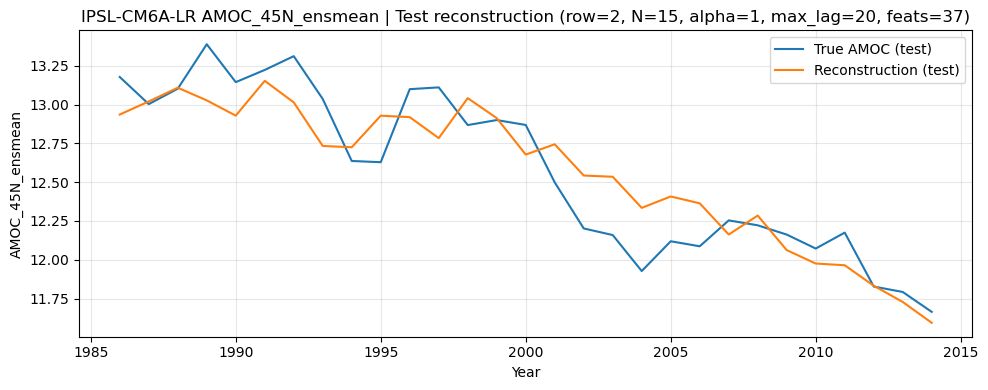

In [3]:
# ============================================================
# PLOT: choose run by row-index from the saved sweep metrics CSV
# ============================================================

import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# ----------------------------
# USER CHOICE
# ----------------------------
RUN_INDEX = 2   # 0-based index into the metrics CSV rows (e.g., 0->N=5, 1->N=10, 2->N=15, ...)
# If you want to override alpha manually, set this to a number; otherwise keep None
ALPHA_OVERRIDE = None

# ----------------------------
# Load sweep metrics + pick run
# ----------------------------
metrics_csv = out_csv  # produced earlier in your script
df_metrics = pd.read_csv(metrics_csv)

if RUN_INDEX < 0 or RUN_INDEX >= len(df_metrics):
    raise IndexError(f"RUN_INDEX={RUN_INDEX} out of range. metrics has {len(df_metrics)} rows (0..{len(df_metrics)-1}).")

run = df_metrics.iloc[int(RUN_INDEX)]
N_chosen = int(run["N_seeds"])
alpha_chosen = float(run["alpha"]) if ALPHA_OVERRIDE is None else float(ALPHA_OVERRIDE)

print("\nSelected run from metrics CSV:")
print(run.to_string())
print(f"\nUsing: N={N_chosen}, alpha={alpha_chosen}")

# ----------------------------
# Rebuild features + X/Y for chosen N
# ----------------------------
df_top = df_rank.head(N_chosen)
feats = build_selected_feature_set(df_top)

X, t_out, max_lag = build_X_from_features(pc_np, common_years, feats)
Y = AMOC[max_lag:]  # aligns with X rows

print(f"\nRebuilt from top-{N_chosen}: n_features={len(feats)}  computed max_lag={max_lag}")

# Compare with what was saved in the sweep metrics (helpful sanity check)
saved_max_lag = int(run["max_lag_used"])
saved_nfeat = int(run["n_features_after_window"])
if max_lag != saved_max_lag or len(feats) != saved_nfeat:
    print(f"⚠️ Note: rebuilt differs from saved sweep row:")
    print(f"   saved: n_features={saved_nfeat}, max_lag={saved_max_lag}")
    print(f"   now  : n_features={len(feats)}, max_lag={max_lag}")
    print("   This usually happens if LAG_WINDOW / CAP_LAGS_PER_GROUP / MAX_LAG_ALLOWED changed since you made the CSV.")

# ----------------------------
# Train/test split (same logic as sweep)
# ----------------------------
n_train = int((1 - TEST_FRAC) * len(X))
Xtr, Xte = X[:n_train], X[n_train:]
Ytr, Yte = Y[:n_train], Y[n_train:]
t_test = t_out[n_train:]

# ----------------------------
# Fit + predict
# ----------------------------
mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha_chosen))
mdl.fit(Xtr, Ytr)
pred = mdl.predict(Xte)

r2_t, r_t, var_t = metrics(Yte, pred)
print(f"\nTEST METRICS (selected run): R²={r2_t:.4f}  corr={r_t:.4f}  var={var_t:.3f}")

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_test, Yte, label="True AMOC (test)")
plt.plot(t_test, pred, label="Reconstruction (test)")
plt.xlabel("Year")
plt.ylabel(TARGET)  # you said this is already converted (Sv)
plt.title(
    f"{MODEL} {TARGET} | Test reconstruction (row={RUN_INDEX}, N={N_chosen}, alpha={alpha_chosen:g}, "
    f"max_lag={max_lag}, feats={len(feats)})"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_png = os.path.join(
    OUTDIR,
    f"{MODEL}_{TARGET}_test_recon_row{int(RUN_INDEX)}_N{N_chosen}_alpha{alpha_chosen:g}_lag{max_lag}.png"
)
plt.savefig(out_png, dpi=200)
print("Saved plot:", out_png)
plt.show()


/tmp/ipykernel_847088/211268569.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


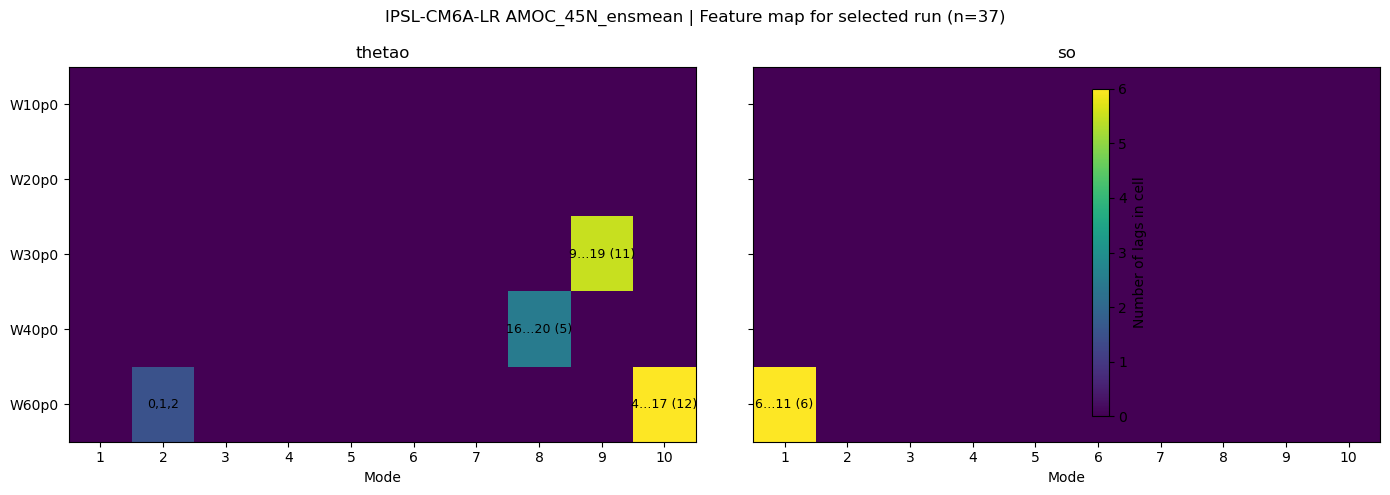

In [7]:
# ============================================================
# EASY FEATURE MAP: two-panel (thetao / so) table-heatmap
# Each cell shows the lag(s) selected for that (lon, mode)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _make_lag_grid(feats, var, lon_tags, n_modes):
    """Return a 2D array of strings: [lon_index, mode_index] -> 'lags' """
    grid = np.full((len(lon_tags), n_modes), "", dtype=object)

    # collect lags per (lon, mode)
    d = {}
    for (v, lon, mode0, lag) in feats:
        if v != var:
            continue
        key = (lon, mode0)
        d.setdefault(key, set()).add(int(lag))

    # fill grid strings
    for i, lon in enumerate(lon_tags):
        for m0 in range(n_modes):
            lags = sorted(d.get((lon, m0), []))
            if len(lags) == 0:
                grid[i, m0] = ""
            elif len(lags) <= 4:
                grid[i, m0] = ",".join(map(str, lags))
            else:
                grid[i, m0] = f"{lags[0]}…{lags[-1]} ({len(lags)})"
    return grid

def plot_feature_map_table(feats, lon_tags, n_modes, title="Selected features"):
    # build grids
    grid_T = _make_lag_grid(feats, "thetao", lon_tags, n_modes)
    grid_S = _make_lag_grid(feats, "so", lon_tags, n_modes)

    # a simple background shading = count of lags in each cell (helps the eye)
    def count_grid(grid):
        out = np.zeros(grid.shape, float)
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                s = grid[i, j].strip()
                if s == "":
                    out[i, j] = 0
                elif "…" in s:
                    # parse "(N)" if present
                    if "(" in s and ")" in s:
                        out[i, j] = float(s.split("(")[-1].split(")")[0])
                    else:
                        out[i, j] = 5.0
                else:
                    out[i, j] = float(len(s.split(",")))
        return out

    bg_T = count_grid(grid_T)
    bg_S = count_grid(grid_S)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, grid, bg, varname in zip(
        axes, [grid_T, grid_S], [bg_T, bg_S], ["thetao", "so"]
    ):
        im = ax.imshow(bg, aspect="auto")  # no explicit colors set (matplotlib default)

        # annotate with lags
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                if grid[i, j] != "":
                    ax.text(j, i, grid[i, j], ha="center", va="center", fontsize=9)

        ax.set_title(f"{varname}")
        ax.set_xticks(range(n_modes))
        ax.set_xticklabels([str(m+1) for m in range(n_modes)])
        ax.set_xlabel("Mode")
        ax.set_yticks(range(len(lon_tags)))
        ax.set_yticklabels(lon_tags)
        ax.grid(False)

    fig.suptitle(title)
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label("Number of lags in cell")
    plt.tight_layout()
    plt.show()


# ---- Use it (feats should be your selected list of 37 features) ----
plot_feature_map_table(
    feats,
    lon_tags=LON_TAGS,
    n_modes=N_MODES,
    title=f"{MODEL} {TARGET} | Feature map for selected run (n={len(feats)})"
)


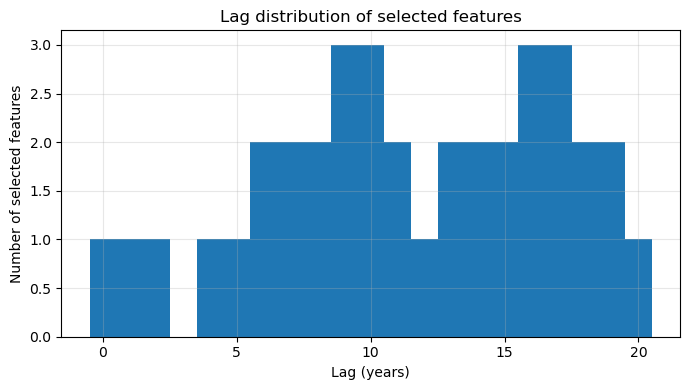

In [5]:
# ============================================================
# HISTOGRAM: Lag distribution
# ============================================================

lags = [f[3] for f in feats]

plt.figure(figsize=(7,4))
plt.hist(lags, bins=np.arange(min(lags), max(lags)+2)-0.5)
plt.xlabel("Lag (years)")
plt.ylabel("Number of selected features")
plt.title("Lag distribution of selected features")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
#!/usr/bin/env python3
"""
SAVE TOP-N SEEDS ONLY (no lag-window expansion)
----------------------------------------------
Reads your top50 mode–lag features CSV (seeds) and saves only the top N seeds
to a new CSV.

Why you want this:
- Your ridge sweep script expands each seed into lag-window features.
- This script lets you keep only the raw seeds (var, lon, mode, lag) for plotting,
  reporting, or later controlled expansion.

Input expected columns:
  var, lon, mode, lag, abs_corr   (corr optional)

Outputs:
  *_top15_SEEDS.csv  (and optionally a mode0 column for 0-based indexing)
"""

import os
import pandas as pd

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

# Point this to the seed file you already created (top50 list)
INFILE = (
    f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/"
    f"{MODEL}_{TARGET}_top50_mode_lag_features_LAGMAX25.csv"
)

# Where to save the top seeds
OUTDIR = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/"
os.makedirs(OUTDIR, exist_ok=True)

N_SEEDS = 15

# If your CSV "mode" is 1..10 (common), set True so we also write mode0 = mode-1
MODE_IS_1BASED = True

# If you want to ensure unique seeds (avoid any duplicates), set True
DROP_DUPLICATES = True
DUP_COLS = ["var", "lon", "mode", "lag"]  # uniqueness definition

# Which column decides ranking:
# prefer abs_corr if present, else fallback to abs(corr) if corr exists
RANK_COL = "abs_corr"

# ============================================================
# LOAD + CHECK
# ============================================================

df = pd.read_csv(INFILE)

required_any = {"abs_corr", "corr"}
if not required_any.intersection(df.columns):
    raise ValueError(f"Input must contain at least one of {required_any}. Found columns: {list(df.columns)}")

# Ensure abs_corr exists
if "abs_corr" not in df.columns:
    df["abs_corr"] = df["corr"].abs()

# Basic required columns for seed definition
for c in ["var", "lon", "mode", "lag"]:
    if c not in df.columns:
        raise ValueError(f"Missing required column '{c}'. Found columns: {list(df.columns)}")

# Optional dedup
if DROP_DUPLICATES:
    before = len(df)
    df = df.drop_duplicates(subset=DUP_COLS).copy()
    after = len(df)
    print(f"Dropped duplicates: {before-after} removed (kept {after})")

# Sort by importance
df = df.sort_values(RANK_COL, ascending=False).reset_index(drop=True)

# Take top N
top = df.head(N_SEEDS).copy()

# Add 0-based mode column for safe numpy indexing
if MODE_IS_1BASED:
    top["mode0"] = top["mode"].astype(int) - 1
else:
    top["mode0"] = top["mode"].astype(int)

# ============================================================
# SAVE
# ============================================================

tag = "MODE1BASED" if MODE_IS_1BASED else "MODE0BASED"
outfile = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_top{N_SEEDS}_SEEDS_{tag}.csv")
top.to_csv(outfile, index=False)

print("Saved:", outfile)
print("\nPreview:")
print(top.head(10).to_string(index=False))


Dropped duplicates: 0 removed (kept 50)
Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top15_SEEDS_MODE1BASED.csv

Preview:
       model           target    var   lon  mode  lag      corr  abs_corr  mode0
IPSL-CM6A-LR AMOC_45N_ensmean thetao W30p0     9   16 -0.693010  0.693010      8
IPSL-CM6A-LR AMOC_45N_ensmean thetao W30p0     9   15 -0.677937  0.677937      8
IPSL-CM6A-LR AMOC_45N_ensmean thetao W30p0     9   17 -0.674132  0.674132      8
IPSL-CM6A-LR AMOC_45N_ensmean thetao W30p0     9   12 -0.666395  0.666395      8
IPSL-CM6A-LR AMOC_45N_ensmean thetao W40p0     8   18 -0.665700  0.665700      7
IPSL-CM6A-LR AMOC_45N_ensmean thetao W30p0     9   11 -0.664254  0.664254      8
IPSL-CM6A-LR AMOC_45N_ensmean thetao W60p0    10    6 -0.662385  0.662385      9
IPSL-CM6A-LR AMOC_45N_ensmean thetao W30p0     9   13 -0.661551  0.661551      8
IPSL-CM6A-LR AMOC_45N_ensmean thetao W60p0    10    7 -0.659048  0.659048  

Reading:
  /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/IPSL-CM6A-LR_AMOC_45N_ensmean_ridge_topN_sweep_window_metrics.csv
  /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/IPSL-CM6A-LR_AMOC_45N_ensmean_BEST_features_window.csv
Saving figures to: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES


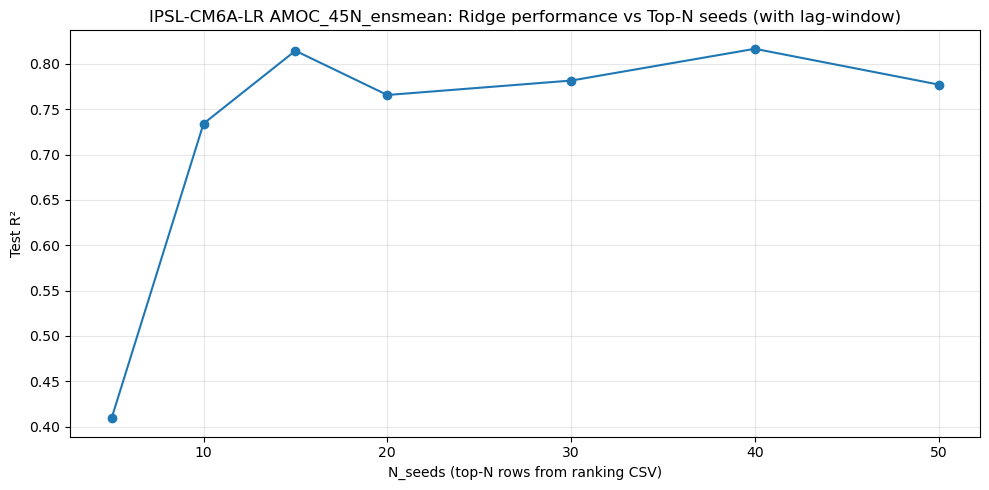

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG1_R2_vs_Nseeds.png


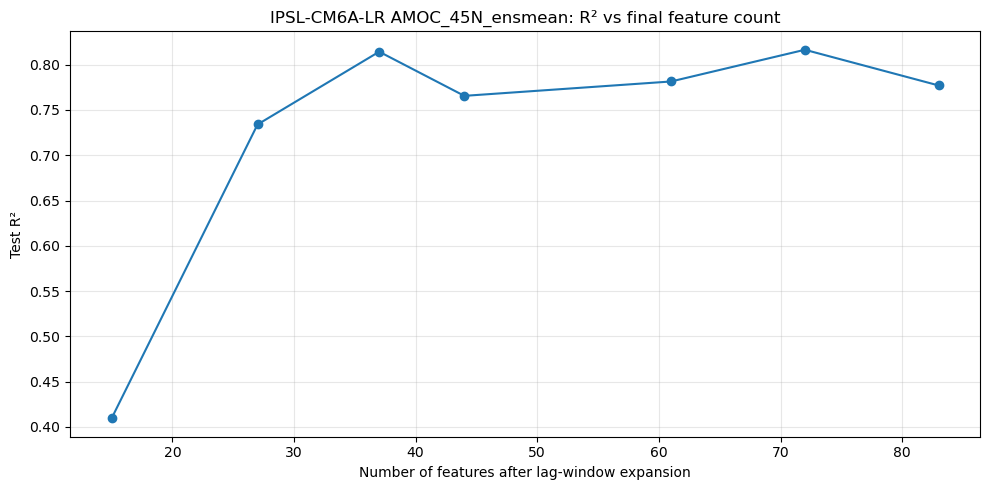

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG1b_R2_vs_featurecount.png


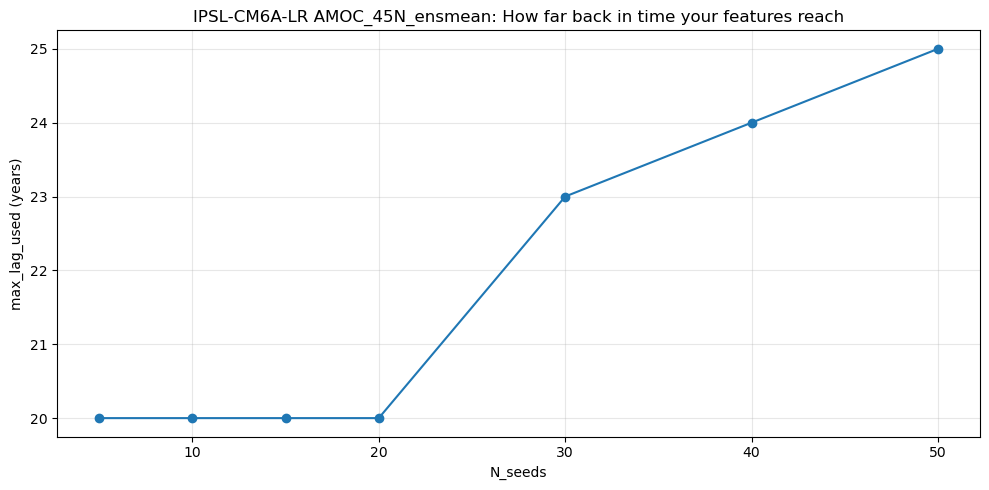

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG2_maxlag_vs_Nseeds.png


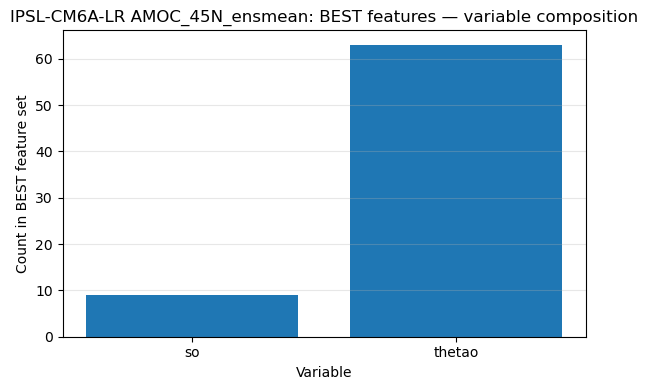

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG3a_best_var_counts.png


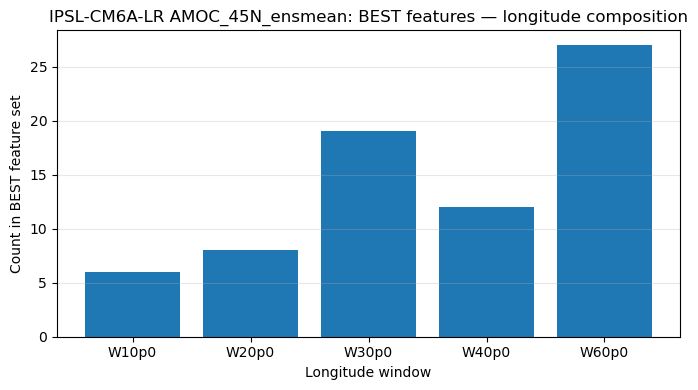

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG3b_best_lon_counts.png


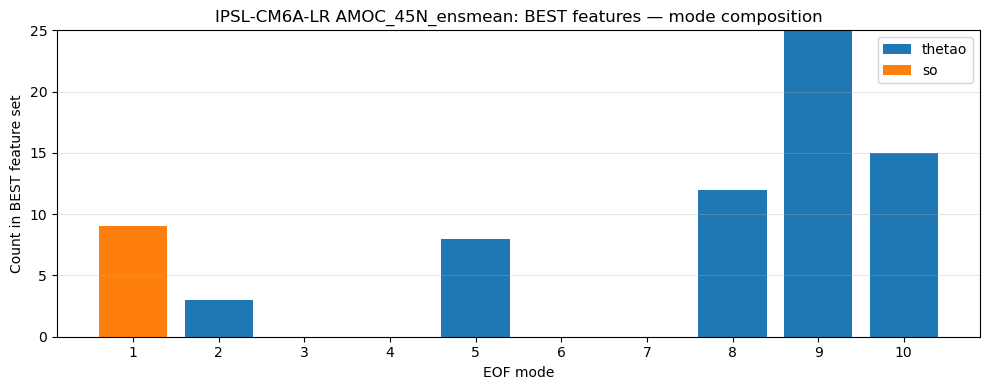

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG3c_best_mode_counts_stacked.png


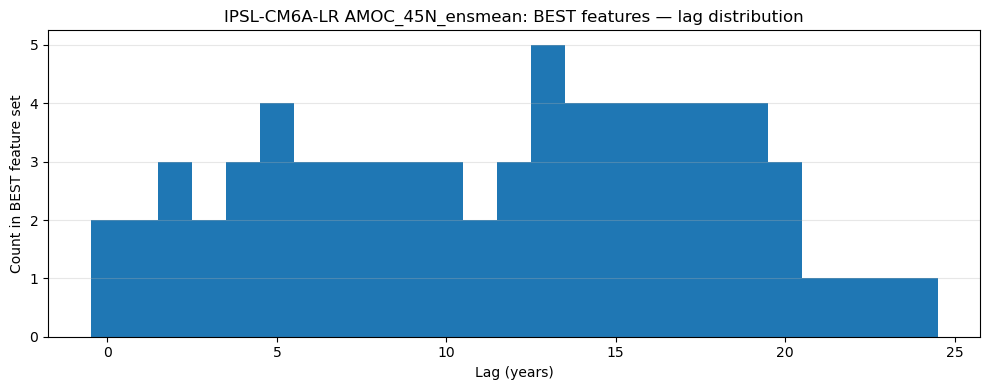

Saved: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES/IPSL-CM6A-LR_AMOC_45N_ensmean_FIG4_best_lag_hist.png

✅ DONE — figures written to: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW/FIGURES


In [11]:
#!/usr/bin/env python3
"""
MAKE FIGURES FROM TOPN-WINDOW SWEEP OUTPUTS
------------------------------------------
Inputs (from the new sweep script):
  1) *_ridge_topN_sweep_window_metrics.csv
  2) *_BEST_features_window.csv

Outputs:
  FIG1: R² vs N_seeds (and n_features)
  FIG2: max_lag_used vs N_seeds
  FIG3: Best feature composition (var/lon/mode counts)
  FIG4: Best feature lag histogram
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG — EDIT THESE
# ============================================================
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

OUTDIR = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/RIDGE_TOPN_SWEEP_WINDOW/"

METRICS_CSV = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_ridge_topN_sweep_window_metrics.csv")
BEST_CSV    = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_BEST_features_window.csv")

FIGDIR = os.path.join(OUTDIR, "FIGURES")
os.makedirs(FIGDIR, exist_ok=True)

print("Reading:")
print(" ", METRICS_CSV)
print(" ", BEST_CSV)
print("Saving figures to:", FIGDIR)

# ============================================================
# LOAD
# ============================================================
df = pd.read_csv(METRICS_CSV)
best = pd.read_csv(BEST_CSV)  # columns: var, lon, mode0, lag

# ============================================================
# FIG 1 — R² vs N (and feature count)
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(df["N_seeds"], df["r2"], marker="o", label="Test R²")
plt.xlabel("N_seeds (top-N rows from ranking CSV)")
plt.ylabel("Test R²")
plt.title(f"{MODEL} {TARGET}: Ridge performance vs Top-N seeds (with lag-window)")
plt.grid(alpha=0.3)
plt.tight_layout()
f1 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG1_R2_vs_Nseeds.png")
#plt.savefig(f1, dpi=300)
plt.show()
print("Saved:", f1)

# Optional: R² vs number of final features after expansion
plt.figure(figsize=(10,5))
plt.plot(df["n_features_after_window"], df["r2"], marker="o")
plt.xlabel("Number of features after lag-window expansion")
plt.ylabel("Test R²")
plt.title(f"{MODEL} {TARGET}: R² vs final feature count")
plt.grid(alpha=0.3)
plt.tight_layout()
f1b = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG1b_R2_vs_featurecount.png")
#plt.savefig(f1b, dpi=300)
plt.show()
print("Saved:", f1b)

# ============================================================
# FIG 2 — max_lag_used vs N
# ============================================================
plt.figure(figsize=(10,5))
plt.plot(df["N_seeds"], df["max_lag_used"], marker="o")
plt.xlabel("N_seeds")
plt.ylabel("max_lag_used (years)")
plt.title(f"{MODEL} {TARGET}: How far back in time your features reach")
plt.grid(alpha=0.3)
plt.tight_layout()
f2 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG2_maxlag_vs_Nseeds.png")
#plt.savefig(f2, dpi=300)
plt.show()
print("Saved:", f2)

# ============================================================
# FIG 3 — BEST feature composition (counts)
# ============================================================
best["mode"] = best["mode0"].astype(int) + 1  # nicer (1-based)

# 3a) counts by variable
var_counts = best["var"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(var_counts.index, var_counts.values)
plt.xlabel("Variable")
plt.ylabel("Count in BEST feature set")
plt.title(f"{MODEL} {TARGET}: BEST features — variable composition")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
f3a = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG3a_best_var_counts.png")
#plt.savefig(f3a, dpi=300)
plt.show()
print("Saved:", f3a)

# 3b) counts by longitude
lon_counts = best["lon"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar(lon_counts.index, lon_counts.values)
plt.xlabel("Longitude window")
plt.ylabel("Count in BEST feature set")
plt.title(f"{MODEL} {TARGET}: BEST features — longitude composition")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
f3b = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG3b_best_lon_counts.png")
#plt.savefig(f3b, dpi=300)
plt.show()
print("Saved:", f3b)

# 3c) counts by mode (stacked by var)
modes = np.arange(1, 11)
theta = best[best["var"]=="thetao"]["mode"].value_counts()
sal   = best[best["var"]=="so"]["mode"].value_counts()
theta_vals = np.array([theta.get(m, 0) for m in modes])
sal_vals   = np.array([sal.get(m, 0) for m in modes])

plt.figure(figsize=(10,4))
plt.bar(modes, theta_vals, label="thetao")
plt.bar(modes, sal_vals, bottom=theta_vals, label="so")
plt.xlabel("EOF mode")
plt.ylabel("Count in BEST feature set")
plt.title(f"{MODEL} {TARGET}: BEST features — mode composition")
plt.xticks(modes)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
f3c = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG3c_best_mode_counts_stacked.png")
#plt.savefig(f3c, dpi=300)
plt.show()
print("Saved:", f3c)

# ============================================================
# FIG 4 — BEST lags histogram
# ============================================================
plt.figure(figsize=(10,4))
plt.hist(best["lag"].astype(int).values, bins=np.arange(best["lag"].min(), best["lag"].max()+2)-0.5)
plt.xlabel("Lag (years)")
plt.ylabel("Count in BEST feature set")
plt.title(f"{MODEL} {TARGET}: BEST features — lag distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
f4 = os.path.join(FIGDIR, f"{MODEL}_{TARGET}_FIG4_best_lag_hist.png")
#plt.savefig(f4, dpi=300)
plt.show()
print("Saved:", f4)

print("\n✅ DONE — figures written to:", FIGDIR)


Loading EOF PCs...
Loading AMOC...
✓ Common years: 1850–2014 (T=165)
✓ PC modes: 10
Loading feature sets...
Top50 features: 50
Seeds file rows: 15
Using seeds: 15 (N_SEEDS_TO_USE=20)
Expanded seed-window features: 37
Max lag Top50: 49
Max lag Seed-window: 20
Using GLOBAL_START_LAG = 49 for aligned X and Y

Fitting baseline Top50...
Fitting compact Top15-seeds-window...

RESULTS:
Baseline Top50: alpha= 100.0 R²= 0.7836056512976999
Compact Top15 seeds: alpha= 10.0 R²= 0.7991045004241489


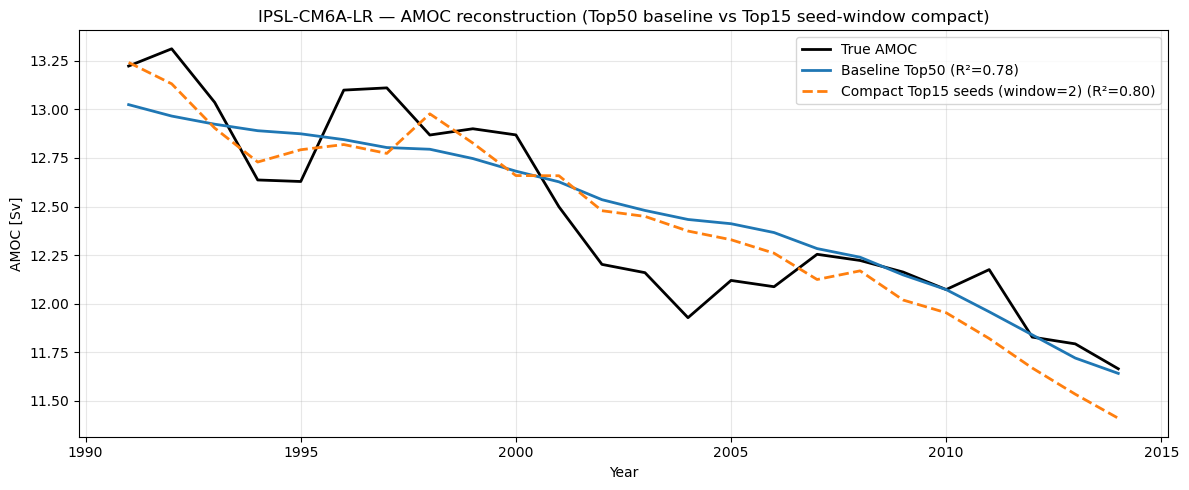


Saved plot: /data/users/frekle/AMOC_analysis/ReconstructionPlots/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_baselineTop50_vs_Top15Seeds_window2_LAGMAXNone.png
✅ DONE.


In [12]:
#!/usr/bin/env python3
"""
TIMESERIES RECONSTRUCTION PLOT — FLEXIBLE #SEEDS
------------------------------------------------
Plots:
  • True AMOC streamfunction
  • Baseline = Top-50 peak features
  • Compact  = Top-N SEEDS expanded with lag-window

Model:  IPSL-CM6A-LR
Target: AMOC_45N_ensmean
"""

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG (EDIT ME)
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Baseline peak features (Top-50)
TOP50_FILE = (
    f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/"
    f"{MODEL}_{TARGET}_top50_mode_lag_features_ALLLAGS.csv"
)

# Seeds CSV (can be "top15", "top30", etc — name doesn't matter)
SEEDS_FILE = (
    f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/"
    f"{MODEL}_{TARGET}_top15_SEEDS_MODE1BASED.csv"
)

# Choose how many seeds to use from the seeds file
N_SEEDS_TO_USE = 20  # <-- change freely

# Lag-window expansion around each seed lag
LAG_WINDOW = 2

# Optional: cap expanded lags to [0 .. LAG_MAX_ALLOWED]
LAG_MAX_ALLOWED = None   # set None to disable cap

# Ridge alpha values
RIDGE_ALPHAS = [0.1, 1, 10, 100, 1000]

TEST_FRAC = 0.2

OUTDIR = f"/data/users/frekle/AMOC_analysis/ReconstructionPlots/{MODEL}/{TARGET}/"
os.makedirs(OUTDIR, exist_ok=True)

# If your seeds file has a score column, you can sort by it.
# Common examples: "importance", "abs_corr", "corr", "score"
# Set to None to keep file order.
SEED_SORT_COL = None   # e.g. "importance"
SEED_SORT_ASC = False  # usually descending is correct

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        return np.array([int(str(x)[:4]) for x in time_coord], dtype=int)

def load_pc(var, lon):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)

    PC = ds["PC"].mean("member")  # ensmean
    PC = PC.transpose("time", "mode")

    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def harmonize_mode_column(df, pc_n_modes):
    """
    Ensure 0-based integer mode index column called 'mode_idx'.
    Accepts:
      - mode0 (already 0-based)
      - mode (might be 1-based or 0-based)
    """
    if "mode0" in df.columns:
        df["mode_idx"] = df["mode0"].astype(int)
        return df

    if "mode" not in df.columns:
        raise ValueError(f"Missing 'mode' or 'mode0'. Columns: {list(df.columns)}")

    mmax = int(df["mode"].max())
    mmin = int(df["mode"].min())

    # If it looks like 1..N, convert to 0..N-1
    if mmin >= 1 and mmax <= pc_n_modes:
        df["mode_idx"] = df["mode"].astype(int) - 1
    else:
        df["mode_idx"] = df["mode"].astype(int)

    if df["mode_idx"].max() >= pc_n_modes or df["mode_idx"].min() < 0:
        raise ValueError(
            f"Mode indexing incompatible. mode_idx range="
            f"{df['mode_idx'].min()}..{df['mode_idx'].max()}, pc_n_modes={pc_n_modes}"
        )
    return df

def expand_seed_lags(seeds_df, window, lag_max=None):
    """
    Expand each seed (var, lon, mode_idx, lag) into lag-window features.
    Returns unique rows: var, lon, mode_idx, lag
    """
    rows = []
    for _, r in seeds_df.iterrows():
        var = r["var"]
        lon = r["lon"]
        mode_idx = int(r["mode_idx"])
        lag0 = int(r["lag"])

        for lag in range(lag0 - window, lag0 + window + 1):
            if lag < 0:
                continue
            if lag_max is not None and lag > int(lag_max):
                continue
            rows.append((var, lon, mode_idx, int(lag)))

    out = pd.DataFrame(rows, columns=["var", "lon", "mode_idx", "lag"])
    out = out.drop_duplicates().sort_values(["var", "lon", "mode_idx", "lag"]).reset_index(drop=True)
    return out

def build_X_from_features(pc_np, years, feature_df, global_start_lag):
    """
    Build X aligned to a single global start lag:
      row at time index t uses predictors from (t - lag)
    feature_df columns: var, lon, mode_idx, lag
    """
    years = np.asarray(years, dtype=int)
    T = len(years)

    # Speed: pre-extract arrays for iteration
    feats_iter = list(feature_df.itertuples(index=False))

    X = []
    time_out = []

    for t in range(global_start_lag, T):
        row = []
        for r in feats_iter:
            var = r.var
            lon = r.lon
            mode = int(r.mode_idx)
            lag  = int(r.lag)
            row.append(pc_np[(var, lon)][t - lag, mode])
        X.append(row)
        time_out.append(years[t])

    return np.asarray(X, dtype=float), np.asarray(time_out, dtype=int)

def ridge_fit(Xtr, Ytr, Xte, Yte):
    best = None
    for a in RIDGE_ALPHAS:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(a)))
        mdl.fit(Xtr, Ytr)
        pred = mdl.predict(Xte)

        r2 = float(r2_score(Yte, pred))
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "pred": pred, "r2": r2}
    return best

# ============================================================
# LOAD PCs
# ============================================================

print("Loading EOF PCs...")
VARS = ["thetao", "so"]
LONS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]

pc_dict = {}
for v in VARS:
    for l in LONS:
        pc_dict[(v, l)] = load_pc(v, l)

# ============================================================
# LOAD AMOC + COMMON YEARS
# ============================================================

print("Loading AMOC...")
dsA = xr.open_dataset(AMOC_FILE)
amoc = dsA[TARGET].squeeze()

years = extract_years(amoc["time"])
amoc = amoc.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, dtype=int)
common_years.sort()

amocY = amoc.sel(year=common_years).values.astype(float).squeeze()

pc_np = {(var, lon): da.sel(year=common_years).values.astype(float) for (var, lon), da in pc_dict.items()}
pc_n_modes = pc_np[(VARS[0], LONS[0])].shape[1]

print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")
print(f"✓ PC modes: {pc_n_modes}")

# ============================================================
# LOAD FEATURE TABLES
# ============================================================

print("Loading feature sets...")

top50 = pd.read_csv(TOP50_FILE)
seeds_all = pd.read_csv(SEEDS_FILE)

top50 = harmonize_mode_column(top50, pc_n_modes)
seeds_all = harmonize_mode_column(seeds_all, pc_n_modes)

# Optionally sort seeds by a score column if present
if SEED_SORT_COL is not None:
    if SEED_SORT_COL not in seeds_all.columns:
        raise ValueError(f"SEED_SORT_COL='{SEED_SORT_COL}' not in seeds file columns: {list(seeds_all.columns)}")
    seeds_all = seeds_all.sort_values(SEED_SORT_COL, ascending=SEED_SORT_ASC).reset_index(drop=True)

# Take top N seeds (or all if file is shorter)
N_USE = int(min(N_SEEDS_TO_USE, len(seeds_all)))
seeds_use = seeds_all.iloc[:N_USE].copy()

# Expand seeds into lag-window features
seed_window_feats = expand_seed_lags(seeds_use, window=LAG_WINDOW, lag_max=LAG_MAX_ALLOWED)

print("Top50 features:", len(top50))
print(f"Seeds file rows: {len(seeds_all)}")
print(f"Using seeds: {N_USE} (N_SEEDS_TO_USE={N_SEEDS_TO_USE})")
print("Expanded seed-window features:", len(seed_window_feats))

top50_feat = top50[["var", "lon", "mode_idx", "lag"]].copy()
seed_feat  = seed_window_feats[["var", "lon", "mode_idx", "lag"]].copy()

# ============================================================
# GLOBAL ALIGNMENT (same start lag for both X50 and Xseed)
# ============================================================

maxlag_50 = int(top50_feat["lag"].max())
maxlag_s  = int(seed_feat["lag"].max()) if len(seed_feat) > 0 else 0
GLOBAL_START_LAG = max(maxlag_50, maxlag_s)

print(f"Max lag Top50: {maxlag_50}")
print(f"Max lag Seed-window: {maxlag_s}")
print(f"Using GLOBAL_START_LAG = {GLOBAL_START_LAG} for aligned X and Y")

# ============================================================
# BUILD X MATRICES (aligned)
# ============================================================

X50, time_out = build_X_from_features(pc_np, common_years, top50_feat, GLOBAL_START_LAG)
Xsd, _        = build_X_from_features(pc_np, common_years, seed_feat,  GLOBAL_START_LAG)

Yuse = amocY[GLOBAL_START_LAG:]  # aligned to time_out

# ============================================================
# TRAIN/TEST SPLIT
# ============================================================

n_train = int((1 - TEST_FRAC) * len(Yuse))

Ytr, Yte = Yuse[:n_train], Yuse[n_train:]
t_test   = time_out[n_train:]

X50tr, X50te = X50[:n_train], X50[n_train:]
Xsdtr, Xsdte = Xsd[:n_train], Xsd[n_train:]

# ============================================================
# FIT MODELS
# ============================================================

print("\nFitting baseline Top50...")
base = ridge_fit(X50tr, Ytr, X50te, Yte)

print(f"Fitting compact Top{N_USE}-seeds-window...")
comp = ridge_fit(Xsdtr, Ytr, Xsdte, Yte)

print("\nRESULTS:")
print("Baseline Top50: alpha=", base["alpha"], "R²=", base["r2"])
print(f"Compact Top{N_USE} seeds: alpha=", comp["alpha"], "R²=", comp["r2"])

# ============================================================
# PLOT TIMESERIES
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(t_test, Yte, color="black", lw=2, label="True AMOC")

plt.plot(
    t_test, base["pred"], lw=2,
    label=f"Baseline Top50 (R²={base['r2']:.2f})"
)

plt.plot(
    t_test, comp["pred"], lw=2, linestyle="--",
    label=f"Compact Top{N_USE} seeds (window={LAG_WINDOW}) (R²={comp['r2']:.2f})"
)

plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} — AMOC reconstruction (Top50 baseline vs Top{N_USE} seed-window compact)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

tag = f"Top{N_USE}Seeds_window{LAG_WINDOW}_LAGMAX{LAG_MAX_ALLOWED if LAG_MAX_ALLOWED is not None else 'None'}"
fout = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_baselineTop50_vs_{tag}.png")
plt.savefig(fout, dpi=300)
plt.show()

print("\nSaved plot:", fout)
print("✅ DONE.")
